# 1\.4\.2 Explore Multimodal Mobility Relationships

This notebook examines how the main mobility signals relate to one another across shared temporal and spatial settings\. The goal is not to generate every possible pairwise chart, but to answer a focused set of multimodal questions that will help us understand which metrics move together, which capture distinct behavior, how those relationships vary across time and geography, and which signals seem most useful to carry forward into later clustering, anomaly\-detection, and supervised\-learning workflows\. We will use the processed 1\.3\.1 outputs as the source, keep sparse contextual signals honest, and focus on insight generation rather than broad visual coverage\.

### Questions we will answer in this notebook

This notebook focuses on a small set of multimodal questions that can generate useful insight for later clustering, anomaly detection, supervised learning, and forecasting\. We are not trying to exhaust every possible pairwise comparison or build a giant correlation catalog\. Instead, the notebook is organized around four analytical blocks that help us understand which mobility signals move together, which diverge, how those relationships change across policy regime and geography, and which signals seem distinct enough to preserve downstream\.

Broad co\-movement and divergence across modalities

Which core mobility metrics tend to move together at the citywide level, and which appear to capture different behavior?
Are Taxi and FHVHV mostly redundant signals, or do they show meaningfully different temporal patterns?
Does Subway ridership move with for\-hire demand, against it, or in a more independent way?
Does Bus speed behave more like a demand signal, a performance signal, or something orthogonal to the other main modes?
Which multimodal relationships look strong and stable enough to be treated as meaningful structure rather than noise?

Substitution, complementarity, and policy\-regime change

Do relationships among Taxi, FHVHV, Subway, and Bus change after congestion pricing?
Are any substitution\-like relationships stronger in the post\-CP period than in the pre\-CP period?
Do multimodal relationships look stable across temporal buckets, or do they vary sharply by time of day?
When two modes move in opposite directions, does that pattern look localized and occasional, or broad enough to matter analytically?
Do the pre/post relationship changes look immediate, gradual, or inconsistent across the study period?

Spatial heterogeneity in multimodal relationships

Do multimodal relationships look different in Manhattan/CBD\-oriented zones than in the rest of the city?
Are there selected high\-interest zones where the multimodal relationships look especially different from the citywide pattern?
Do citywide multimodal summaries hide important local variation in how the modes relate to one another?
Do the same places stand out before and after congestion pricing, or does the geography of multimodal behavior shift?
Are multimodal relationships broadly consistent across space, or concentrated in a smaller set of zones?

Downstream signal value for clustering and anomaly workflows

Which base metrics appear to contribute genuinely distinct signal, and which look potentially redundant?
Which modalities seem important to keep separate in the Chapter 3 clustering and anomaly backbone?
Which contextual signals seem more useful for interpretation than for core anomaly modeling?
Which multimodal patterns seem stable and interpretable enough to inform later supervised\-learning feature design?
What did this notebook teach us about the distinctiveness, stability, and usefulness of the main mobility signals?

In [1]:
# Setup: imports, paths, metric backbone, and lightweight helpers

from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from project_branding import (
    BRAND_COLORS,
    BRAND_COLOR_SEQUENCE,
    BRAND_DIVERGING_SEQUENCE,
    BRAND_MAP_COLORS,
)

sns.set_theme(style="whitegrid", palette=BRAND_COLOR_SEQUENCE)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

PIPELINE_DATA_DIR = Path("pipeline_data")
MERGED_FINAL_DIR = PIPELINE_DATA_DIR / "1.3.1.final_tables"
SPATIAL_CONTEXT_DIR = PIPELINE_DATA_DIR / "1.2.6.final_tables"
OUTPUT_DIR = PIPELINE_DATA_DIR / "1.4.2.outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_PANEL_PATH = MERGED_FINAL_DIR / "analysis_ready_mobility_panel.parquet"
AUDIT_PANEL_PATH = MERGED_FINAL_DIR / "audit_only_mobility_panel.parquet"
SPATIAL_CONTEXT_PATH = SPATIAL_CONTEXT_DIR / "taxi_zone_spatial_context.parquet"
WEATHER_CONTEXT_PATH = MERGED_FINAL_DIR / "weather_taxi_zone_context.parquet"
BRIDGE_TUNNEL_CONTEXT_PATH = MERGED_FINAL_DIR / "bridge_tunnel_mobility_panel.parquet"

STUDY_START_DATE = pd.Timestamp("2023-01-01")
STUDY_END_DATE = pd.Timestamp("2026-03-31")
CONGESTION_PRICING_START_DATE = pd.Timestamp("2025-01-05")

SAVE_FIGURES = False
INCLUDE_WEATHER_CONTEXT = False
INCLUDE_BRIDGE_TUNNEL_CONTEXT = False

TEMPORAL_BUCKET_ORDER = [
    "weekday_overnight",
    "weekday_am_peak",
    "weekday_midday",
    "weekday_pm_peak",
    "weekday_evening",
    "weekend_overnight",
    "weekend_am_peak",
    "weekend_midday",
    "weekend_pm_peak",
    "weekend_evening",
]

CORE_METRICS = [
    "taxi_trip_count",
    "taxi_avg_trip_speed",
    "fhvhv_trip_count",
    "fhvhv_avg_trip_speed",
    "subway_ridership",
    "avg_bus_speed",
]

METRIC_LABELS = {
    "taxi_trip_count": "Taxi trips",
    "taxi_avg_trip_speed": "Taxi average speed",
    "fhvhv_trip_count": "FHVHV trips",
    "fhvhv_avg_trip_speed": "FHVHV average speed",
    "subway_ridership": "Subway ridership",
    "avg_bus_speed": "Average bus speed",
}

PRIMARY_PAIR_DEFINITIONS = [
    ("primary_cross_modality", "taxi_trip_count", "subway_ridership"),
    ("primary_cross_modality", "taxi_trip_count", "fhvhv_trip_count"),
    ("primary_cross_modality", "fhvhv_trip_count", "subway_ridership"),
    ("primary_cross_modality", "taxi_avg_trip_speed", "avg_bus_speed"),
    ("primary_cross_modality", "taxi_trip_count", "avg_bus_speed"),
    ("primary_cross_modality", "subway_ridership", "avg_bus_speed"),
]

SUPPORTING_PAIR_DEFINITIONS = [
    ("supporting_same_modality", "taxi_trip_count", "taxi_avg_trip_speed"),
    ("supporting_same_modality", "fhvhv_trip_count", "fhvhv_avg_trip_speed"),
]

BRAND_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "brand_diverging",
    BRAND_DIVERGING_SEQUENCE,
)

POLICY_GEOGRAPHY_ORDER = [
    "cbd",
    "gateway_to_cbd",
    "adjacent_to_cbd",
    "non_cbd",
]

con = duckdb.connect()

print("[1.4.2] Setup loaded.")

[1.4.2] Setup loaded.


## 1\.4\.2\.1 Define notebook scope, metric shortlist, and comparison cuts

This short setup section just locks the notebook onto the right data, the six\-metric backbone, and the small set of comparison cuts we will reuse\. We are not re\-running broad exploratory QA or re\-deciding the metric universe here\. The goal is simply to make the rest of the notebook clean, consistent, and focused on the multimodal questions that actually matter\.

### Confirm source tables and working analytical grain

We will confirm the processed 1\.3\.1 tables we want to use for the notebook and the working grain we will analyze from\. The notebook should stay grounded in the canonical Taxi Zone × Date × Temporal Bucket structure or in clean aggregates derived from it, without introducing new restructuring logic\.

In [2]:
# Confirm source tables and working analytical grain

artifact_specs = [
    {
        "artifact": "analysis_ready_mobility_panel",
        "path": ANALYSIS_PANEL_PATH,
        "notebook_role": "primary notebook backbone",
        "working_grain": "taxi_zone x date x temporal_bucket",
        "zone_col": "taxi_zone_id",
        "date_col": "date",
        "bucket_col": "temporal_bucket",
    },
    {
        "artifact": "taxi_zone_spatial_context",
        "path": SPATIAL_CONTEXT_PATH,
        "notebook_role": "zone labels, policy geography, and static spatial context",
        "working_grain": "one row per taxi_zone_id",
        "zone_col": "canonical_location_id",
        "date_col": None,
        "bucket_col": None,
    },
    {
        "artifact": "weather_taxi_zone_context",
        "path": WEATHER_CONTEXT_PATH,
        "notebook_role": "optional supporting context only",
        "working_grain": "taxi_zone x date x temporal_bucket",
        "zone_col": "taxi_zone_id",
        "date_col": "date",
        "bucket_col": "temporal_bucket",
    },
    {
        "artifact": "bridge_tunnel_mobility_panel",
        "path": BRIDGE_TUNNEL_CONTEXT_PATH,
        "notebook_role": "optional supporting context only",
        "working_grain": "system-level date x temporal_bucket",
        "zone_col": None,
        "date_col": "date",
        "bucket_col": "temporal_bucket",
    },
]

artifact_inventory_records = []

for spec in artifact_specs:
    path_str = spec["path"].as_posix()
    path_exists = spec["path"].exists()

    record = {
        "artifact": spec["artifact"],
        "path": path_str,
        "exists": path_exists,
        "notebook_role": spec["notebook_role"],
        "working_grain": spec["working_grain"],
        "row_count": np.nan,
        "distinct_taxi_zones": np.nan,
        "distinct_dates": np.nan,
        "distinct_temporal_buckets": np.nan,
        "min_date": pd.NaT,
        "max_date": pd.NaT,
    }

    if path_exists:
        row_count = con.execute(
            f"SELECT COUNT(*) AS row_count FROM read_parquet('{path_str}')"
        ).df().iloc[0, 0]
        record["row_count"] = int(row_count)

        if spec["zone_col"] is not None:
            zone_count = con.execute(
                f"SELECT COUNT(DISTINCT {spec['zone_col']}) AS distinct_zone_count FROM read_parquet('{path_str}')"
            ).df().iloc[0, 0]
            record["distinct_taxi_zones"] = int(zone_count)

        if spec["date_col"] is not None:
            date_summary_df = con.execute(
                f"""
                SELECT
                    COUNT(DISTINCT {spec['date_col']}) AS distinct_dates,
                    MIN({spec['date_col']}) AS min_date,
                    MAX({spec['date_col']}) AS max_date
                FROM read_parquet('{path_str}')
                """
            ).df()
            record["distinct_dates"] = int(date_summary_df.loc[0, "distinct_dates"])
            record["min_date"] = date_summary_df.loc[0, "min_date"]
            record["max_date"] = date_summary_df.loc[0, "max_date"]

        if spec["bucket_col"] is not None:
            bucket_count = con.execute(
                f"SELECT COUNT(DISTINCT {spec['bucket_col']}) AS distinct_bucket_count FROM read_parquet('{path_str}')"
            ).df().iloc[0, 0]
            record["distinct_temporal_buckets"] = int(bucket_count)

    artifact_inventory_records.append(record)

# This keeps the notebook honest about the few companion datasets it may reference later
# without turning the opening into a full QA section.
source_table_inventory_df = pd.DataFrame(artifact_inventory_records)

display(source_table_inventory_df)

,artifact,path,exists,notebook_role,working_grain,row_count,distinct_taxi_zones,distinct_dates,distinct_temporal_buckets,min_date,max_date
0,analysis_ready_mobility_panel,pipeline_data/1.3.1.final_tables/analysis_read...,True,primary notebook backbone,taxi_zone x date x temporal_bucket,1559590,263.0,1186.0,10.0,2023-01-01,2026-03-31
1,taxi_zone_spatial_context,pipeline_data/1.2.6.final_tables/taxi_zone_spa...,True,"zone labels, policy geography, and static spat...",one row per taxi_zone_id,264,262.0,NaN,NaN,NaT,NaT
2,weather_taxi_zone_context,pipeline_data/1.3.1.final_tables/weather_taxi_...,True,optional supporting context only,taxi_zone x date x temporal_bucket,1537120,260.0,1183.0,10.0,2023-01-01,2026-03-31
3,bridge_tunnel_mobility_panel,pipeline_data/1.3.1.final_tables/bridge_tunnel...,True,optional supporting context only,system-level date x temporal_bucket,112657,NaN,1186.0,10.0,2023-01-01,2026-03-31


### Define the core multimodal metric shortlist

We are not re\-opening the full metric\-selection debate here\. Instead, we will reaffirm the small backbone we already trust most for multimodal relationship work: Taxi activity and speed, FHVHV activity and speed, Subway ridership, and average bus speed\. Bus trip count can still help as a weighting field for bus\-speed aggregation, but it is not part of the main relationship backbone\.

In [3]:
# Define the core multimodal metric shortlist

metric_shortlist_df = pd.DataFrame(
    {
        "metric": CORE_METRICS,
        "metric_label": [METRIC_LABELS[m] for m in CORE_METRICS],
        "modality": [
            "taxi",
            "taxi",
            "fhvhv",
            "fhvhv",
            "subway",
            "bus",
        ],
        "signal_role": [
            "activity",
            "performance",
            "activity",
            "performance",
            "activity",
            "performance",
        ],
        "notebook_role": [
            "primary backbone",
            "primary backbone",
            "primary backbone",
            "primary backbone",
            "primary backbone",
            "primary backbone",
        ],
        "why_it_stays": [
            "Main Taxi demand signal.",
            "Best Taxi surface-performance signal.",
            "Main FHVHV demand signal.",
            "Best FHVHV surface-performance signal.",
            "Clearest transit-demand signal.",
            "Best bus network performance signal.",
        ],
    }
)

display(metric_shortlist_df)

,metric,metric_label,modality,signal_role,notebook_role,why_it_stays
0,taxi_trip_count,Taxi trips,taxi,activity,primary backbone,Main Taxi demand signal.
1,taxi_avg_trip_speed,Taxi average speed,taxi,performance,primary backbone,Best Taxi surface-performance signal.
2,fhvhv_trip_count,FHVHV trips,fhvhv,activity,primary backbone,Main FHVHV demand signal.
3,fhvhv_avg_trip_speed,FHVHV average speed,fhvhv,performance,primary backbone,Best FHVHV surface-performance signal.
4,subway_ridership,Subway ridership,subway,activity,primary backbone,Clearest transit-demand signal.
5,avg_bus_speed,Average bus speed,bus,performance,primary backbone,Best bus network performance signal.


### Define comparison cuts and grouping lenses

We will define the shared comparison cuts that organize the rest of the notebook: citywide summaries, pre/post congestion\-pricing splits, temporal\-bucket views, policy\-geography cuts, and the selected high\-interest Taxi Zones we already identified in 1\.4\.1\. Keeping these lenses stable will make the later comparisons easier to read and easier to trust\.

In [4]:
# Define comparison cuts and grouping lenses

selected_zone_reference_df = pd.DataFrame(
    [
        {"taxi_zone_id": 237, "selection_reason": "manhattan_taxi_anchor"},
        {"taxi_zone_id": 230, "selection_reason": "manhattan_subway_anchor"},
        {"taxi_zone_id": 70, "selection_reason": "outer_borough_taxi_anchor"},
        {"taxi_zone_id": 61, "selection_reason": "outer_borough_fhvhv_anchor"},
        {"taxi_zone_id": 68, "selection_reason": "strongest_positive_shift"},
        {"taxi_zone_id": 5, "selection_reason": "strongest_negative_shift"},
        {"taxi_zone_id": 157, "selection_reason": "most_temporally_distinctive"},
        {"taxi_zone_id": 7, "selection_reason": "outer_borough_balanced_contrast"},
    ]
).merge(
    con.execute(
        f"""
        SELECT DISTINCT
            canonical_location_id AS taxi_zone_id,
            zone,
            borough,
            cbd_spatial_category
        FROM read_parquet('{SPATIAL_CONTEXT_PATH.as_posix()}')
        """
    ).df(),
    on="taxi_zone_id",
    how="left",
)

comparison_lenses_df = pd.DataFrame(
    {
        "comparison_lens": [
            "citywide_daily",
            "pre_post_regime",
            "temporal_bucket",
            "policy_geography",
            "selected_high_interest_zones",
        ],
        "definition": [
            "Collapse the Taxi Zone panel to one citywide daily series per metric.",
            "Split observations into pre_cp and post_cp relative to January 5, 2025.",
            "Keep the shared ten-bucket weekday/weekend temporal structure.",
            "Use cbd / gateway_to_cbd / adjacent_to_cbd / non_cbd groupings.",
            "Reuse the eight selected zones from 1.4.1 for local multimodal spot checks.",
        ],
        "why_we_need_it": [
            "Supports broad multimodal co-movement comparisons.",
            "Supports regime-shift comparisons without causal overclaiming.",
            "Lets us test whether relationships differ by time of day.",
            "Lets us compare Manhattan-oriented areas against the rest of the city.",
            "Lets us check whether local multimodal structure differs from citywide summaries.",
        ],
    }
)

display(comparison_lenses_df)

,comparison_lens,definition,why_we_need_it
0,citywide_daily,Collapse the Taxi Zone panel to one citywide d...,Supports broad multimodal co-movement comparis...
1,pre_post_regime,Split observations into pre_cp and post_cp rel...,Supports regime-shift comparisons without caus...
2,temporal_bucket,Keep the shared ten-bucket weekday/weekend tem...,Lets us test whether relationships differ by t...
3,policy_geography,Use cbd / gateway_to_cbd / adjacent_to_cbd / n...,Lets us compare Manhattan-oriented areas again...
4,selected_high_interest_zones,Reuse the eight selected zones from 1.4.1 for ...,Lets us check whether local multimodal structu...


## 1\.4\.2\.2 Broad co\-movement and divergence across modalities

This section looks at the broad relationship structure first\. The emphasis stays on cross\-modality co\-movement and divergence, with same\-modality demand\-versus\-speed pairs used only as supporting context\. We want a compact read on which signals move together, which clearly do not, and which relationships look stable enough to matter later in clustering and anomaly work\.

### Build aligned citywide multimodal summaries

We will create clean citywide summaries that align the selected metrics on a shared temporal footing\. These summaries should support direct comparison across the main modes without forcing them into a single conceptual category\.

In [5]:
# Build aligned citywide multimodal summaries

citywide_daily_wide_df = con.execute(
    f"""
    SELECT
        CAST(date AS DATE) AS date,
        pre_post_cp,
        SUM(COALESCE(taxi_trip_count, 0)) AS taxi_trip_count,
        CASE
            WHEN SUM(CASE WHEN taxi_avg_trip_speed IS NOT NULL THEN COALESCE(taxi_trip_count, 0) ELSE 0 END) > 0
            THEN SUM(COALESCE(taxi_avg_trip_speed, 0) * COALESCE(taxi_trip_count, 0))
                / SUM(CASE WHEN taxi_avg_trip_speed IS NOT NULL THEN COALESCE(taxi_trip_count, 0) ELSE 0 END)
        END AS taxi_avg_trip_speed,
        SUM(COALESCE(fhvhv_trip_count, 0)) AS fhvhv_trip_count,
        CASE
            WHEN SUM(CASE WHEN fhvhv_avg_trip_speed IS NOT NULL THEN COALESCE(fhvhv_trip_count, 0) ELSE 0 END) > 0
            THEN SUM(COALESCE(fhvhv_avg_trip_speed, 0) * COALESCE(fhvhv_trip_count, 0))
                / SUM(CASE WHEN fhvhv_avg_trip_speed IS NOT NULL THEN COALESCE(fhvhv_trip_count, 0) ELSE 0 END)
        END AS fhvhv_avg_trip_speed,
        SUM(COALESCE(subway_ridership, 0)) AS subway_ridership,
        CASE
            WHEN SUM(CASE WHEN avg_bus_speed IS NOT NULL THEN COALESCE(bus_trip_count, 0) ELSE 0 END) > 0
            THEN SUM(COALESCE(avg_bus_speed, 0) * COALESCE(bus_trip_count, 0))
                / SUM(CASE WHEN avg_bus_speed IS NOT NULL THEN COALESCE(bus_trip_count, 0) ELSE 0 END)
        END AS avg_bus_speed
    FROM read_parquet('{ANALYSIS_PANEL_PATH.as_posix()}')
    GROUP BY 1, 2
    ORDER BY 1
    """
).df()

citywide_daily_long_df = citywide_daily_wide_df.melt(
    id_vars=["date", "pre_post_cp"],
    value_vars=CORE_METRICS,
    var_name="metric",
    value_name="metric_value",
)
citywide_daily_long_df["metric_label"] = citywide_daily_long_df["metric"].map(METRIC_LABELS)

pre_cp_baseline_df = (
    citywide_daily_long_df[citywide_daily_long_df["pre_post_cp"] == "pre_cp"]
    .groupby("metric", as_index=False)["metric_value"]
    .mean()
    .rename(columns={"metric_value": "pre_cp_mean"})
)

citywide_daily_indexed_long_df = citywide_daily_long_df.merge(
    pre_cp_baseline_df,
    on="metric",
    how="left",
)
citywide_daily_indexed_long_df["index_value"] = (
    citywide_daily_indexed_long_df["metric_value"]
    / citywide_daily_indexed_long_df["pre_cp_mean"]
) * 100

citywide_daily_metric_summary_df = (
    citywide_daily_long_df
    .groupby(["metric", "metric_label"], as_index=False)
    .agg(
        non_null_days=("metric_value", lambda s: s.notna().sum()),
        min_value=("metric_value", "min"),
        max_value=("metric_value", "max"),
    )
    .round(3)
)

display(citywide_daily_metric_summary_df)

,metric,metric_label,non_null_days,min_value,max_value
0,avg_bus_speed,Average bus speed,1186,8.024,9.296
1,fhvhv_avg_trip_speed,FHVHV average speed,1186,12.192,19.240
2,fhvhv_trip_count,FHVHV trips,1186,160777.000,951857.000
3,subway_ridership,Subway ridership,1186,0.000,4736294.000
4,taxi_avg_trip_speed,Taxi average speed,1186,8.354,16.100
5,taxi_trip_count,Taxi trips,1186,6269.000,179936.000


Findings\. The citywide daily backbone looks complete and usable across the full study window, with all six core metrics populated for all 1,186 days\. The scale differences are large, which is exactly why the indexed comparisons matter later: Taxi ranges from about 6\.3K to 180K trips per day, FHVHV from about 161K to 952K, and Subway from 0 to 4\.7M riders, while the speed metrics sit in much tighter bands\. At a glance, this confirms that we have a clean, fully aligned citywide daily panel and that the main variation is in the behavior of the series, not in missingness\.

### Compare broad temporal co\-movement across core metrics

We will examine whether the main metrics rise and fall together over time or whether they follow different trajectories\. This is where we assess which modalities appear to carry overlapping signal and which look more independent\.

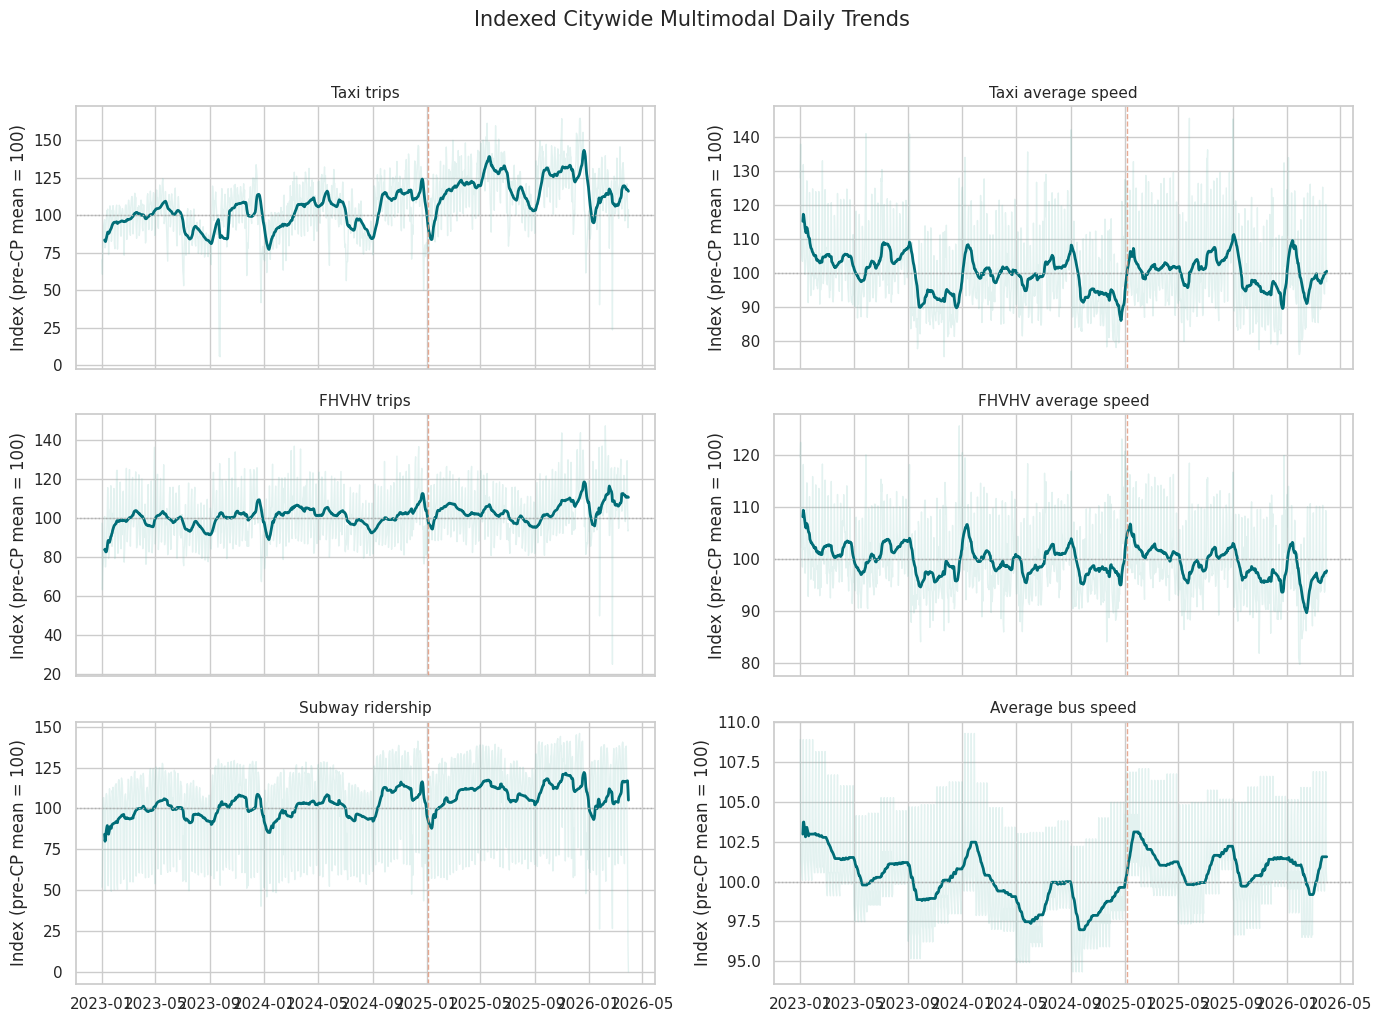

In [6]:
# Compare broad temporal co-movement across core metrics

citywide_daily_indexed_plot_df = citywide_daily_indexed_long_df.copy()
citywide_daily_indexed_plot_df["rolling_index_value"] = (
    citywide_daily_indexed_plot_df
    .groupby("metric")["index_value"]
    .transform(lambda s: s.rolling(21, min_periods=7).mean())
)

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, CORE_METRICS):
    metric_plot_df = citywide_daily_indexed_plot_df[
        citywide_daily_indexed_plot_df["metric"] == metric
    ].copy()

    ax.plot(
        metric_plot_df["date"],
        metric_plot_df["index_value"],
        color=BRAND_COLORS["seafoam"],
        alpha=0.22,
        linewidth=1,
    )
    ax.plot(
        metric_plot_df["date"],
        metric_plot_df["rolling_index_value"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=2,
    )
    ax.axvline(
        CONGESTION_PRICING_START_DATE,
        color=BRAND_COLORS["terracotta"],
        linestyle="--",
        linewidth=1,
        alpha=0.8,
    )
    ax.axhline(100, color="#b0b0b0", linestyle=":", linewidth=1)
    ax.set_title(METRIC_LABELS[metric], fontsize=11)
    ax.set_ylabel("Index (pre-CP mean = 100)")

for ax in axes[len(CORE_METRICS):]:
    ax.axis("off")

fig.suptitle("Indexed Citywide Multimodal Daily Trends", fontsize=15, y=1.02)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / "1.4.2.2_indexed_citywide_multimodal_daily_trends.png", dpi=200, bbox_inches="tight")

plt.show()

Findings\. The indexed view makes the broad structure pretty clear\. Taxi trips, FHVHV trips, and Subway ridership all show a shared upward drift relative to their pre\-CP baselines, although Taxi strengthens the most visibly and FHVHV is the most stable of the three\. The speed metrics tell a different story: Taxi and FHVHV average speeds mostly hover around or slightly below baseline with shorter\-lived spikes, while bus speed looks flatter and more bounded than the other series\. So the first big takeaway is that demand\-side movement is more synchronized across modes than performance\-side movement, which already suggests these metrics are not redundant in the same way\.

### Review compact pairwise relationship structure

We will use a small, targeted set of pairwise comparisons rather than a giant correlation catalog\. The point is to surface the strongest and most interpretable multimodal relationships, while leaving same\-modality demand\-versus\-speed pairs as secondary supporting lenses\.

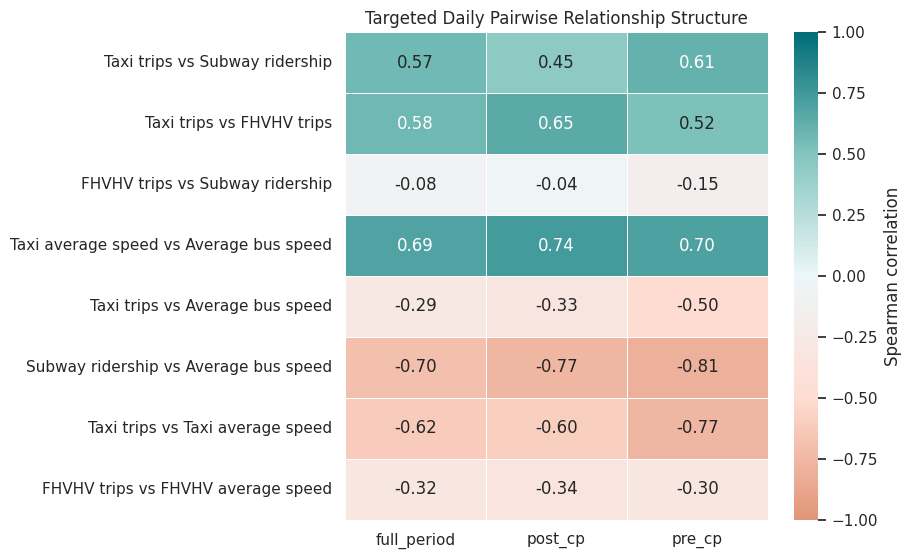

In [7]:
# Review compact pairwise relationship structure

pairwise_relationship_records = []

for pair_type, metric_x, metric_y in PRIMARY_PAIR_DEFINITIONS + SUPPORTING_PAIR_DEFINITIONS:
    pair_label = f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}"

    for period_label, period_filter in [
        ("full_period", citywide_daily_wide_df["date"].notna()),
        ("pre_cp", citywide_daily_wide_df["pre_post_cp"] == "pre_cp"),
        ("post_cp", citywide_daily_wide_df["pre_post_cp"] == "post_cp"),
    ]:
        pair_slice_df = citywide_daily_wide_df.loc[
            period_filter,
            [metric_x, metric_y],
        ].dropna()

        pairwise_relationship_records.append(
            {
                "pair_type": pair_type,
                "pair_label": pair_label,
                "period": period_label,
                "spearman_correlation": pair_slice_df[metric_x].corr(
                    pair_slice_df[metric_y],
                    method="spearman",
                ) if len(pair_slice_df) > 1 else np.nan,
                "matched_days": len(pair_slice_df),
            }
        )

pairwise_relationship_summary_df = pd.DataFrame(pairwise_relationship_records)

pairwise_relationship_heatmap_df = (
    pairwise_relationship_summary_df
    .pivot(index="pair_label", columns="period", values="spearman_correlation")
    .loc[[
        f"{METRIC_LABELS[x]} vs {METRIC_LABELS[y]}"
        for _, x, y in PRIMARY_PAIR_DEFINITIONS + SUPPORTING_PAIR_DEFINITIONS
    ]]
)

plt.figure(figsize=(9, 5.75))
sns.heatmap(
    pairwise_relationship_heatmap_df,
    annot=True,
    fmt=".2f",
    cmap=BRAND_DIVERGING_CMAP.reversed(),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"},
)
plt.title("Targeted Daily Pairwise Relationship Structure")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / "1.4.2.2_targeted_pairwise_relationship_heatmap.png", dpi=200, bbox_inches="tight")

plt.show()

Findings\. The pairwise structure is already pretty informative\. Taxi trips move with both Subway ridership and FHVHV trips at a moderate positive level, which makes those look more like shared\-demand signals than clean substitutes at the citywide daily level\. The clearest positive relationship is Taxi average speed versus Average bus speed, which suggests the two surface\-performance measures are responding to common network conditions\. On the negative side, Subway ridership versus Average bus speed is strongly inverse throughout, and Taxi trips versus Taxi average speed is also meaningfully negative, which is exactly the kind of demand\-versus\-performance tension we would expect when heavier activity lines up with slower movement\. What stands out most is that these relationships are fairly stable across pre\-CP and post\-CP periods, with the biggest differences mostly showing up as strength changes rather than sign flips\.

## 1\.4\.2\.3 Substitution, complementarity, and policy\-regime change

This section asks whether the multimodal relationship structure itself changes after congestion pricing\. We are not trying to make causal claims about substitution or complementarity, but we do want to see whether some pairings become more tightly aligned, more weakly aligned, or more inversely related across policy regimes and temporal buckets\. That gives us a clearer sense of which multimodal patterns are stable, which are regime\-sensitive, and which are worth carrying forward into later anomaly and supervised\-learning work\.

### Compare pre/post multimodal relationships

Before we get fancy, let’s look at the core relationship structure directly\. This block compares a small set of high\-value pairwise relationships before and after congestion pricing so we can see whether the basic co\-movement pattern changed across regimes\.

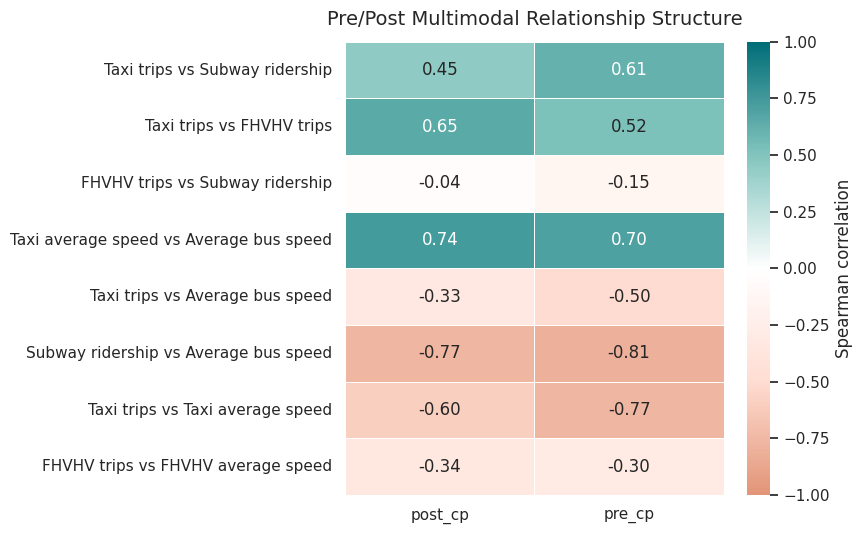

In [8]:
# ---------------------------------------------------------------------
# Compare pre/post multimodal relationships
# ---------------------------------------------------------------------

RELATIONSHIP_PAIRS = [
    ("cross_modal", "taxi_trip_count", "subway_ridership"),
    ("cross_modal", "taxi_trip_count", "fhvhv_trip_count"),
    ("cross_modal", "fhvhv_trip_count", "subway_ridership"),
    ("cross_modal", "taxi_avg_trip_speed", "avg_bus_speed"),
    ("cross_modal", "taxi_trip_count", "avg_bus_speed"),
    ("cross_modal", "subway_ridership", "avg_bus_speed"),
    ("supporting_same_mode", "taxi_trip_count", "taxi_avg_trip_speed"),
    ("supporting_same_mode", "fhvhv_trip_count", "fhvhv_avg_trip_speed"),
]

regime_relationship_records = []

for pair_type, metric_x, metric_y in RELATIONSHIP_PAIRS:
    pair_label = f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}"

    for regime_label in ["pre_cp", "post_cp"]:
        pair_slice_df = citywide_daily_wide_df.loc[
            citywide_daily_wide_df["pre_post_cp"] == regime_label,
            ["date", metric_x, metric_y],
        ].dropna()

        regime_relationship_records.append(
            {
                "pair_type": pair_type,
                "pair_label": pair_label,
                "policy_regime": regime_label,
                "metric_x": metric_x,
                "metric_y": metric_y,
                "spearman_correlation": (
                    pair_slice_df[metric_x].corr(pair_slice_df[metric_y], method="spearman")
                    if len(pair_slice_df) > 1 else np.nan
                ),
                "matched_days": len(pair_slice_df),
            }
        )

regime_relationship_df = pd.DataFrame(regime_relationship_records)

regime_relationship_heatmap_df = (
    regime_relationship_df
    .pivot(index="pair_label", columns="policy_regime", values="spearman_correlation")
    .loc[
        [f"{METRIC_LABELS[x]} vs {METRIC_LABELS[y]}" for _, x, y in RELATIONSHIP_PAIRS]
    ]
)

regime_relationship_change_df = (
    regime_relationship_df
    .pivot(
        index=["pair_type", "pair_label", "metric_x", "metric_y"],
        columns="policy_regime",
        values=["spearman_correlation", "matched_days"],
    )
)
regime_relationship_change_df.columns = [
    f"{value}_{regime}" for value, regime in regime_relationship_change_df.columns
]
regime_relationship_change_df = (
    regime_relationship_change_df
    .reset_index()
    .assign(
        correlation_change=lambda df: (
            df["spearman_correlation_post_cp"] - df["spearman_correlation_pre_cp"]
        )
    )
    .round(3)
)

relationship_cmap = LinearSegmentedColormap.from_list(
    "relationship_cmap",
    [
        BRAND_COLORS["dark_teal"],
        BRAND_COLORS["seafoam"],
        "#ffffff",
        BRAND_COLORS["pale_peach"],
        BRAND_COLORS["terracotta"],
        
    ],
).reversed()

plt.figure(figsize=(8.5, 5.5))
sns.heatmap(
    regime_relationship_heatmap_df,
    annot=True,
    fmt=".2f",
    cmap=relationship_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"},
)
plt.title("Pre/Post Multimodal Relationship Structure", fontsize=14, pad=12)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        EDA_OUTPUT_DIR / "1.4.2.3_pre_post_relationship_structure.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

A small companion table makes the regime shift easier to read without staring at the heatmap\. This is just the same relationship structure, but now expressed as the pre/post change in correlation strength\.

In [9]:
# ---------------------------------------------------------------------
# Summarize pre/post relationship change
# ---------------------------------------------------------------------

display(
    regime_relationship_change_df[
        [
            "pair_type",
            "pair_label",
            "spearman_correlation_pre_cp",
            "spearman_correlation_post_cp",
            "correlation_change",
            "matched_days_pre_cp",
            "matched_days_post_cp",
        ]
    ].sort_values("correlation_change", ascending=False)
)

,pair_type,pair_label,spearman_correlation_pre_cp,spearman_correlation_post_cp,correlation_change,matched_days_pre_cp,matched_days_post_cp
3,cross_modal,Taxi trips vs Average bus speed,-0.505,-0.334,0.171,735.0,451.0
7,supporting_same_mode,Taxi trips vs Taxi average speed,-0.769,-0.599,0.170,735.0,451.0
4,cross_modal,Taxi trips vs FHVHV trips,0.517,0.654,0.137,735.0,451.0
0,cross_modal,FHVHV trips vs Subway ridership,-0.155,-0.042,0.113,735.0,451.0
2,cross_modal,Taxi average speed vs Average bus speed,0.698,0.741,0.044,735.0,451.0
1,cross_modal,Subway ridership vs Average bus speed,-0.805,-0.766,0.039,735.0,451.0
6,supporting_same_mode,FHVHV trips vs FHVHV average speed,-0.299,-0.337,-0.039,735.0,451.0
5,cross_modal,Taxi trips vs Subway ridership,0.613,0.450,-0.163,735.0,451.0


Findings\. The pre/post relationship structure suggests that congestion pricing did not rewrite the multimodal system, but it did shift a few relationships in meaningful ways\. The clearest change is that Taxi trips became less tightly tied to Subway ridership after congestion pricing, falling from 0\.613 to 0\.450, while Taxi trips became more tightly aligned with FHVHV trips, rising from 0\.517 to 0\.654\. Taxi trips also became less strongly inverse to both Average bus speed and Taxi average speed, which suggests that the usual “more demand, slower movement” pattern softened somewhat in the post\-policy period\. FHVHV trips and Subway ridership also moved closer to neutral, weakening their already modest inverse relationship\. At the same time, some relationships barely changed at all: Taxi average speed stayed strongly aligned with Average bus speed, and Subway ridership stayed strongly inverse to Average bus speed in both periods\. So the main takeaway is that the post\-congestion\-pricing regime looks less like a total structural break and more like a selective reshaping, especially around how Taxi demand relates to Subway demand, FHVHV demand, and surface performance\.

The pre/post split tells us whether a relationship changed, but not whether it changed abruptly, drifted over time, or bounced around\. This next view tracks one or two high\-value pairings through time so we can see whether the relationship shift looks immediate, gradual, or unstable across the study period\.

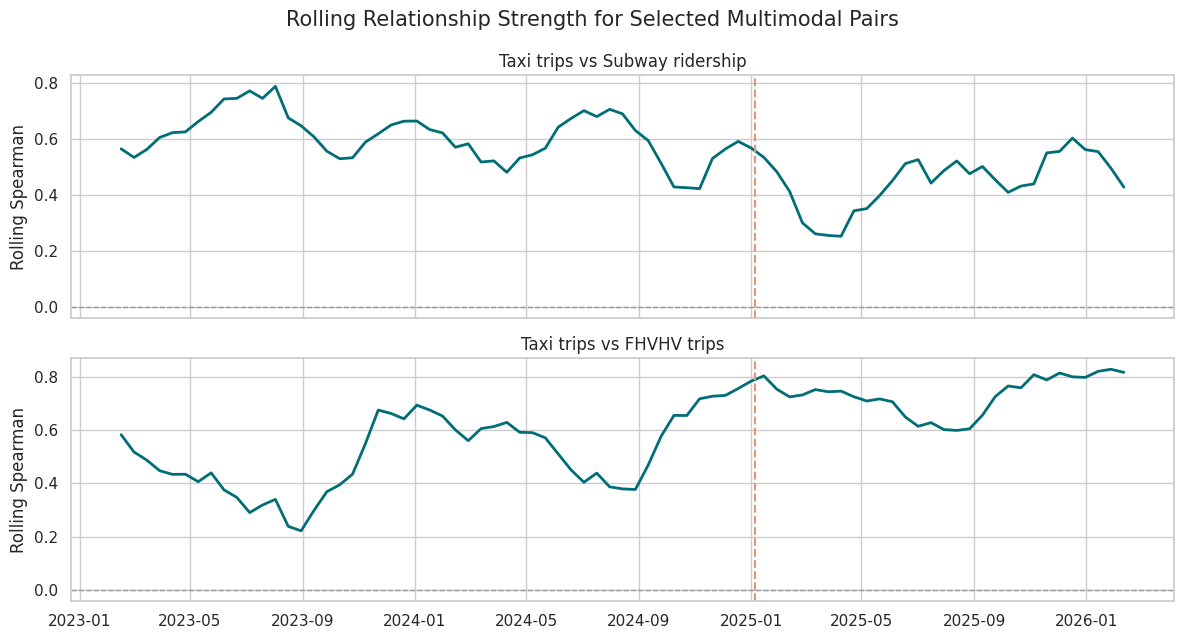

In [10]:
# ---------------------------------------------------------------------
# Track relationship strength through time for two high-value pairings
# ---------------------------------------------------------------------

rolling_pair_definitions = [
    ("taxi_trip_count", "subway_ridership"),
    ("taxi_trip_count", "fhvhv_trip_count"),
]

rolling_corr_records = []
rolling_window_days = 90
rolling_step_days = 14

for metric_x, metric_y in rolling_pair_definitions:
    pair_label = f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}"

    pair_df = (
        citywide_daily_wide_df[["date", metric_x, metric_y]]
        .dropna()
        .sort_values("date")
        .reset_index(drop=True)
    )

    if pair_df.empty:
        continue

    window_start = pair_df["date"].min()
    window_end_limit = pair_df["date"].max()

    while window_start + pd.Timedelta(days=rolling_window_days - 1) <= window_end_limit:
        window_end = window_start + pd.Timedelta(days=rolling_window_days - 1)

        window_df = pair_df.loc[
            pair_df["date"].between(window_start, window_end),
            [metric_x, metric_y],
        ].dropna()

        x_unique = window_df[metric_x].nunique()
        y_unique = window_df[metric_y].nunique()

        rolling_corr_records.append(
            {
                "pair_label": pair_label,
                "window_start": window_start,
                "window_end": window_end,
                "window_midpoint": window_start + pd.Timedelta(days=rolling_window_days // 2),
                "rolling_spearman_correlation": (
                    window_df[metric_x].corr(window_df[metric_y], method="spearman")
                    if len(window_df) >= 45 and x_unique > 1 and y_unique > 1
                    else np.nan
                ),
                "matched_days": len(window_df),
            }
        )

        window_start = window_start + pd.Timedelta(days=rolling_step_days)

rolling_relationship_df = pd.DataFrame(rolling_corr_records)

fig, axes = plt.subplots(len(rolling_pair_definitions), 1, figsize=(12, 6.5), sharex=True)

if len(rolling_pair_definitions) == 1:
    axes = [axes]

for ax, (metric_x, metric_y) in zip(axes, rolling_pair_definitions):
    pair_label = f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}"
    plot_df = rolling_relationship_df.loc[
        rolling_relationship_df["pair_label"] == pair_label
    ].copy()

    ax.plot(
        plot_df["window_midpoint"],
        plot_df["rolling_spearman_correlation"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=2,
    )
    ax.axhline(0, color="#999999", linewidth=1, linestyle="--")
    ax.axvline(
        CONGESTION_PRICING_START_DATE,
        color=BRAND_COLORS["terracotta"],
        linewidth=1.5,
        linestyle="--",
    )
    ax.set_title(pair_label, fontsize=12)
    ax.set_ylabel("Rolling Spearman")

plt.suptitle("Rolling Relationship Strength for Selected Multimodal Pairs", fontsize=15, y=0.98)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        OUTPUT_DIR / "1.4.2.3_rolling_relationship_strength.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. Taxi trips vs Subway ridership is positive throughout the study period, but its strength moves around a lot\. It rises into mid\-2023, softens through parts of 2024, dips sharply in early 2025, then partially recovers without returning to its earlier highs\. Taxi trips vs FHVHV trips also stays positive throughout, but the pattern is steadier after late 2024 and remains strong through most of 2025 and early 2026\. So the main difference is that Taxi/Subway looks more volatile over time, while Taxi/FHVHV settles into a stronger and more durable alignment\.

### Inspect relationship differences across temporal buckets

Some multimodal relationships may look stable at the full\-period daily level but behave very differently across times of day\. This block checks whether those relationship patterns are concentrated in particular temporal buckets rather than being constant across the whole day\.

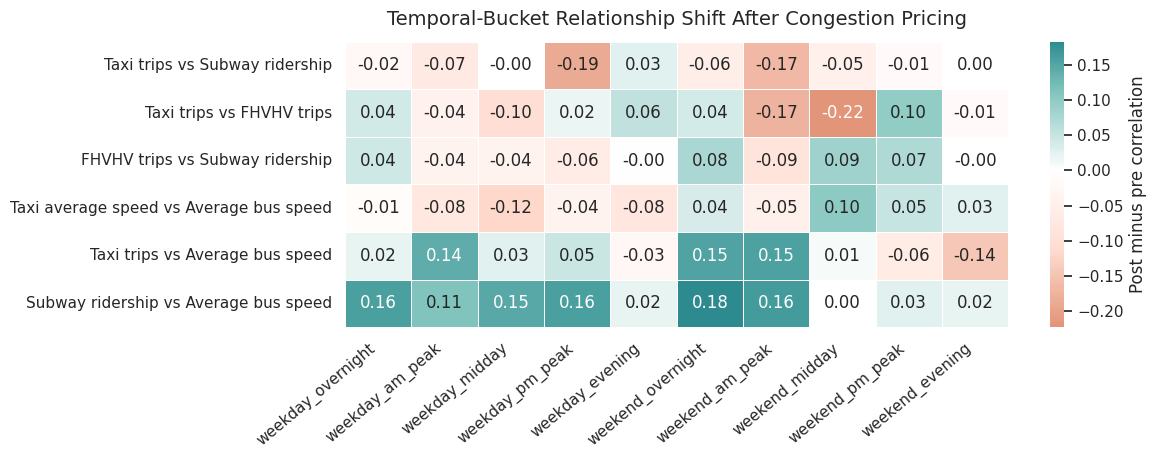

In [11]:
# ---------------------------------------------------------------------
# Inspect relationship differences across temporal buckets
# ---------------------------------------------------------------------

citywide_bucket_wide_df = con.execute(
    f"""
    SELECT
        CAST(date AS DATE) AS date,
        pre_post_cp,
        temporal_bucket,
        SUM(COALESCE(taxi_trip_count, 0)) AS taxi_trip_count,
        CASE
            WHEN SUM(CASE WHEN taxi_avg_trip_speed IS NOT NULL THEN COALESCE(taxi_trip_count, 0) ELSE 0 END) > 0
            THEN SUM(COALESCE(taxi_avg_trip_speed, 0) * COALESCE(taxi_trip_count, 0))
                / SUM(CASE WHEN taxi_avg_trip_speed IS NOT NULL THEN COALESCE(taxi_trip_count, 0) ELSE 0 END)
        END AS taxi_avg_trip_speed,
        SUM(COALESCE(fhvhv_trip_count, 0)) AS fhvhv_trip_count,
        CASE
            WHEN SUM(CASE WHEN fhvhv_avg_trip_speed IS NOT NULL THEN COALESCE(fhvhv_trip_count, 0) ELSE 0 END) > 0
            THEN SUM(COALESCE(fhvhv_avg_trip_speed, 0) * COALESCE(fhvhv_trip_count, 0))
                / SUM(CASE WHEN fhvhv_avg_trip_speed IS NOT NULL THEN COALESCE(fhvhv_trip_count, 0) ELSE 0 END)
        END AS fhvhv_avg_trip_speed,
        SUM(COALESCE(subway_ridership, 0)) AS subway_ridership,
        CASE
            WHEN SUM(CASE WHEN avg_bus_speed IS NOT NULL THEN COALESCE(bus_trip_count, 0) ELSE 0 END) > 0
            THEN SUM(COALESCE(avg_bus_speed, 0) * COALESCE(bus_trip_count, 0))
                / SUM(CASE WHEN avg_bus_speed IS NOT NULL THEN COALESCE(bus_trip_count, 0) ELSE 0 END)
        END AS avg_bus_speed
    FROM read_parquet('{ANALYSIS_PANEL_PATH.as_posix()}')
    GROUP BY 1, 2, 3
    ORDER BY 1, 3
    """
).df()

bucket_relationship_records = []

for _, metric_x, metric_y in RELATIONSHIP_PAIRS:
    pair_label = f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}"

    for regime_label in ["pre_cp", "post_cp"]:
        for temporal_bucket in TEMPORAL_BUCKET_ORDER:
            pair_slice_df = citywide_bucket_wide_df.loc[
                (citywide_bucket_wide_df["pre_post_cp"] == regime_label)
                & (citywide_bucket_wide_df["temporal_bucket"] == temporal_bucket),
                [metric_x, metric_y],
            ].dropna()

            bucket_relationship_records.append(
                {
                    "pair_label": pair_label,
                    "metric_x": metric_x,
                    "metric_y": metric_y,
                    "policy_regime": regime_label,
                    "temporal_bucket": temporal_bucket,
                    "spearman_correlation": (
                        pair_slice_df[metric_x].corr(pair_slice_df[metric_y], method="spearman")
                        if len(pair_slice_df) > 25 else np.nan
                    ),
                    "matched_rows": len(pair_slice_df),
                }
            )

bucket_relationship_df = pd.DataFrame(bucket_relationship_records)

bucket_relationship_change_df = (
    bucket_relationship_df
    .pivot(
        index=["pair_label", "metric_x", "metric_y", "temporal_bucket"],
        columns="policy_regime",
        values=["spearman_correlation", "matched_rows"],
    )
)
bucket_relationship_change_df.columns = [
    f"{value}_{regime}" for value, regime in bucket_relationship_change_df.columns
]
bucket_relationship_change_df = (
    bucket_relationship_change_df
    .reset_index()
    .assign(
        correlation_change=lambda df: (
            df["spearman_correlation_post_cp"] - df["spearman_correlation_pre_cp"]
        )
    )
)

primary_pair_labels = [
    f"{METRIC_LABELS[x]} vs {METRIC_LABELS[y]}"
    for pair_type, x, y in RELATIONSHIP_PAIRS
    if pair_type == "cross_modal"
]

bucket_relationship_heatmap_df = (
    bucket_relationship_change_df.loc[
        bucket_relationship_change_df["pair_label"].isin(primary_pair_labels)
    ]
    .pivot(index="pair_label", columns="temporal_bucket", values="correlation_change")
    .reindex(index=primary_pair_labels, columns=TEMPORAL_BUCKET_ORDER)
    .round(3)
)

bucket_change_cmap = LinearSegmentedColormap.from_list(
    "bucket_change_cmap",
    [
        BRAND_COLORS["dark_teal"],
        BRAND_COLORS["seafoam"],
        "#ffffff",
        BRAND_COLORS["pale_peach"],
        BRAND_COLORS["terracotta"],
    ],
).reversed()

plt.figure(figsize=(12, 4.75))
sns.heatmap(
    bucket_relationship_heatmap_df,
    annot=True,
    fmt=".2f",
    cmap=bucket_change_cmap,
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Post minus pre correlation"},
)
plt.title("Temporal-Bucket Relationship Shift After Congestion Pricing", fontsize=14, pad=12)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        OUTPUT_DIR / "1.4.2.3_temporal_bucket_relationship_shift.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

This companion table surfaces the biggest temporal\-bucket relationship shifts directly, so we can see which pairings changed most and where those changes were concentrated\.

In [12]:
# ---------------------------------------------------------------------
# Summarize strongest temporal-bucket relationship shifts
# ---------------------------------------------------------------------

display(
    bucket_relationship_change_df[
        [
            "pair_label",
            "temporal_bucket",
            "spearman_correlation_pre_cp",
            "spearman_correlation_post_cp",
            "correlation_change",
            "matched_rows_pre_cp",
            "matched_rows_post_cp",
        ]
    ]
    .dropna(subset=["correlation_change"])
    .sort_values("correlation_change", ascending=False)
    .round(3)
    .reset_index(drop=True)
)

,pair_label,temporal_bucket,spearman_correlation_pre_cp,spearman_correlation_post_cp,correlation_change,matched_rows_pre_cp,matched_rows_post_cp
0,Taxi trips vs Taxi average speed,weekday_overnight,-0.731,-0.461,0.270,525.0,322.0
1,Subway ridership vs Average bus speed,weekend_overnight,-0.509,-0.326,0.183,210.0,129.0
2,Subway ridership vs Average bus speed,weekend_am_peak,-0.734,-0.570,0.164,210.0,129.0
3,Subway ridership vs Average bus speed,weekday_overnight,-0.526,-0.368,0.158,525.0,322.0
4,Subway ridership vs Average bus speed,weekday_pm_peak,-0.512,-0.354,0.158,525.0,322.0
5,Taxi trips vs Average bus speed,weekend_am_peak,-0.450,-0.295,0.155,210.0,129.0
6,Taxi trips vs Average bus speed,weekend_overnight,0.069,0.222,0.153,210.0,129.0
7,Subway ridership vs Average bus speed,weekday_midday,-0.712,-0.564,0.148,525.0,322.0
8,Taxi trips vs Taxi average speed,weekend_am_peak,-0.608,-0.463,0.144,210.0,129.0
9,Taxi trips vs Average bus speed,weekday_am_peak,-0.630,-0.489,0.141,525.0,322.0


Findings\. The temporal\-bucket relationship shifts are clearly not uniform across the day\. The largest positive changes are concentrated in overnight and AM\-period buckets, especially for Taxi trips versus Taxi average speed and for Subway ridership versus Average bus speed, where the post\-policy relationships become notably less negative than they were before\. Taxi trips versus Average bus speed also softens in several overnight and AM buckets, and even turns more positive in weekend overnight periods\. At the same time, a different set of relationships weakens in the opposite direction: Taxi trips versus Subway ridership falls most sharply in weekday PM peak and weekend AM periods, while Taxi trips versus FHVHV trips loses some of its strongest alignment in weekend AM and weekend midday\. Taxi average speed versus Average bus speed is split, with stronger weekend midday alignment but weaker weekday AM, midday, and evening alignment\. Overall, the strongest post\-policy relationship changes are concentrated in specific temporal buckets rather than spread evenly across the day, with overnight, AM, and selected peak periods carrying most of the movement\.

### Identify candidate substitution and complementarity patterns

Now that we’ve looked at the raw regime and temporal\-bucket shifts, we can translate the strongest patterns into a careful descriptive shortlist\. The point is not to make causal claims, just to flag which relationships look most consistent with inverse movement, shared\-direction movement, or broader systemwide alignment\.

In [13]:
# ---------------------------------------------------------------------
# Identify candidate substitution-like and complementarity-like patterns
# ---------------------------------------------------------------------

pattern_candidate_df = (
    bucket_relationship_change_df[
        [
            "pair_label",
            "metric_x",
            "metric_y",
            "temporal_bucket",
            "spearman_correlation_pre_cp",
            "spearman_correlation_post_cp",
            "correlation_change",
            "matched_rows_pre_cp",
            "matched_rows_post_cp",
        ]
    ]
    .dropna(subset=["spearman_correlation_pre_cp", "spearman_correlation_post_cp"])
    .copy()
)

pattern_candidate_df["relationship_direction_pre"] = np.where(
    pattern_candidate_df["spearman_correlation_pre_cp"] >= 0,
    "shared_direction",
    "inverse_direction",
)
pattern_candidate_df["relationship_direction_post"] = np.where(
    pattern_candidate_df["spearman_correlation_post_cp"] >= 0,
    "shared_direction",
    "inverse_direction",
)
pattern_candidate_df["abs_post_correlation"] = pattern_candidate_df["spearman_correlation_post_cp"].abs()

def classify_candidate(row):
    post_corr = row["spearman_correlation_post_cp"]

    if post_corr <= -0.30:
        return "candidate_substitution_like"
    if post_corr >= 0.30:
        return "candidate_complementarity_like"
    return "weak_or_mixed"

pattern_candidate_df["candidate_pattern"] = pattern_candidate_df.apply(classify_candidate, axis=1)

pattern_candidate_df = (
    pattern_candidate_df.sort_values(
        ["candidate_pattern", "abs_post_correlation", "correlation_change"],
        ascending=[True, False, False],
    )
    .round(3)
    .reset_index(drop=True)
)

display(
    pattern_candidate_df[
        [
            "candidate_pattern",
            "pair_label",
            "temporal_bucket",
            "spearman_correlation_pre_cp",
            "spearman_correlation_post_cp",
            "correlation_change",
            "matched_rows_pre_cp",
            "matched_rows_post_cp",
        ]
    ]
)

,candidate_pattern,pair_label,temporal_bucket,spearman_correlation_pre_cp,spearman_correlation_post_cp,correlation_change,matched_rows_pre_cp,matched_rows_post_cp
0,candidate_complementarity_like,Taxi trips vs FHVHV trips,weekday_overnight,0.843,0.884,0.041,525.0,322.0
1,candidate_complementarity_like,Taxi trips vs FHVHV trips,weekend_evening,0.895,0.880,-0.015,210.0,129.0
2,candidate_complementarity_like,Taxi trips vs Subway ridership,weekend_evening,0.844,0.845,0.001,210.0,129.0
3,candidate_complementarity_like,Taxi trips vs FHVHV trips,weekend_pm_peak,0.717,0.814,0.098,210.0,129.0
4,candidate_complementarity_like,Taxi trips vs Subway ridership,weekday_am_peak,0.870,0.801,-0.069,525.0,322.0
5,candidate_complementarity_like,FHVHV trips vs Subway ridership,weekend_evening,0.770,0.769,-0.001,210.0,129.0
6,candidate_complementarity_like,Taxi trips vs FHVHV trips,weekend_overnight,0.727,0.766,0.039,210.0,129.0
7,candidate_complementarity_like,Taxi trips vs Subway ridership,weekday_evening,0.739,0.765,0.026,525.0,322.0
8,candidate_complementarity_like,Taxi trips vs FHVHV trips,weekday_evening,0.693,0.750,0.057,525.0,322.0
9,candidate_complementarity_like,FHVHV trips vs Subway ridership,weekday_evening,0.740,0.737,-0.003,525.0,322.0


A final compact chart makes the strongest candidate patterns easier to scan\. We’ll keep only the most interpretable post\-policy examples and show whether they look more shared\-direction or inverse\-direction\.

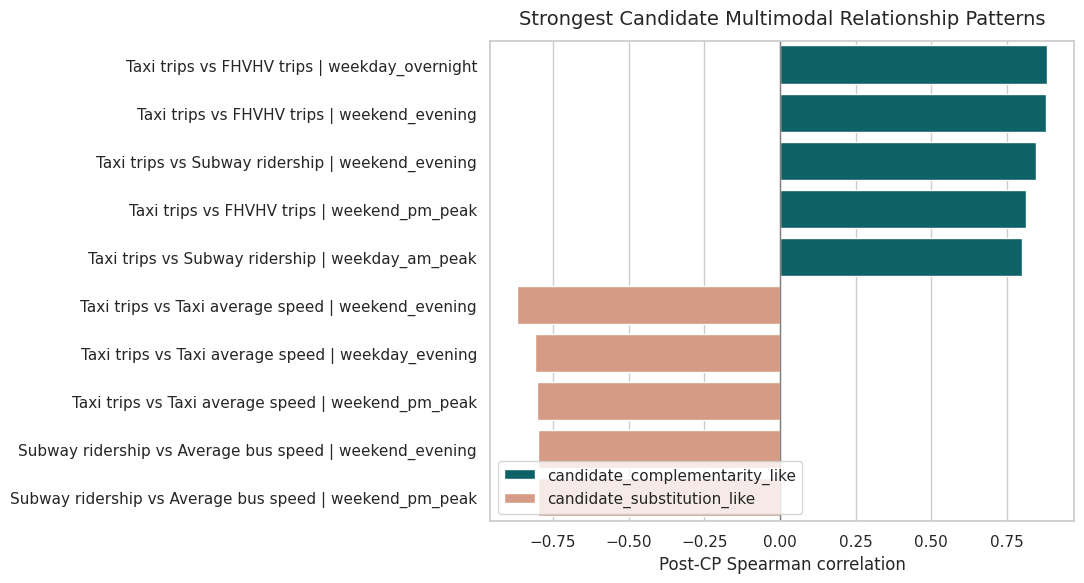

In [14]:
# ---------------------------------------------------------------------
# Visualize strongest candidate relationship patterns
# ---------------------------------------------------------------------

top_pattern_plot_df = pd.concat(
    [
        pattern_candidate_df.loc[
            pattern_candidate_df["candidate_pattern"] == "candidate_complementarity_like"
        ].nlargest(5, "spearman_correlation_post_cp"),
        pattern_candidate_df.loc[
            pattern_candidate_df["candidate_pattern"] == "candidate_substitution_like"
        ].nsmallest(5, "spearman_correlation_post_cp"),
    ],
    ignore_index=True,
)

top_pattern_plot_df["plot_label"] = (
    top_pattern_plot_df["pair_label"] + " | " + top_pattern_plot_df["temporal_bucket"]
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=top_pattern_plot_df,
    y="plot_label",
    x="spearman_correlation_post_cp",
    hue="candidate_pattern",
    palette={
        "candidate_complementarity_like": BRAND_COLORS["dark_teal"],
        "candidate_substitution_like": BRAND_COLORS["terracotta"],
    },
)
plt.axvline(0, color="gray", linewidth=1)
plt.title("Strongest Candidate Multimodal Relationship Patterns", fontsize=14, pad=12)
plt.xlabel("Post-CP Spearman correlation")
plt.ylabel("")
plt.legend(title="")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        EDA_OUTPUT_DIR / "1.4.2.3_candidate_relationship_patterns.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. The strongest candidate complementarity\-like patterns are concentrated in cross\-demand relationships rather than demand\-versus\-speed relationships\. Taxi trips and FHVHV trips stand out most clearly, with very strong positive post\-policy correlations across weekday overnight, weekend evening, weekend PM peak, and weekday evening, all in roughly the 0\.75 to 0\.88 range\. Taxi trips and Subway ridership also remain strongly aligned in a few buckets, especially weekend evening and weekday AM peak, while FHVHV trips and Subway ridership show similarly strong shared\-direction movement in weekend and weekday evening periods\. On the other side, the strongest candidate substitution\-like patterns are dominated by demand\-versus\-speed pairings: Taxi trips versus Taxi average speed and Subway ridership versus Average bus speed remain strongly negative in the highlighted buckets, especially weekend evening and weekend PM peak\. So the clearest descriptive pattern is that the top complementarity\-like signals reflect shared demand movement across modes, while the top substitution\-like signals mostly reflect the familiar inverse relationship between higher activity and slower system performance\.

This small follow\-up answers a practical question the bucket table alone cannot: when we see inverse multimodal movement, is it something broad enough to matter analytically, or just a local/situational pattern? The goal is to classify the strongest inverse relationships by scope and by how often they recur across the shared temporal buckets, rather than leaving them as isolated correlation values\.

In [15]:
# ---------------------------------------------------------------------
# Classify the scope of the strongest inverse multimodal patterns
# ---------------------------------------------------------------------

POLICY_GEOGRAPHY_ORDER = [
    "cbd",
    "gateway_to_cbd",
    "adjacent_to_cbd",
    "non_cbd",
]

zone_daily_wide_df = con.execute(
    f"""
    SELECT
        taxi_zone_id,
        zone,
        borough,
        cbd_spatial_category,
        CAST(date AS DATE) AS date,
        pre_post_cp,
        SUM(COALESCE(taxi_trip_count, 0)) AS taxi_trip_count,
        CASE
            WHEN SUM(CASE WHEN taxi_avg_trip_speed IS NOT NULL THEN COALESCE(taxi_trip_count, 0) ELSE 0 END) > 0
            THEN SUM(COALESCE(taxi_avg_trip_speed, 0) * COALESCE(taxi_trip_count, 0))
                / SUM(CASE WHEN taxi_avg_trip_speed IS NOT NULL THEN COALESCE(taxi_trip_count, 0) ELSE 0 END)
        END AS taxi_avg_trip_speed,
        SUM(COALESCE(fhvhv_trip_count, 0)) AS fhvhv_trip_count,
        CASE
            WHEN SUM(CASE WHEN fhvhv_avg_trip_speed IS NOT NULL THEN COALESCE(fhvhv_trip_count, 0) ELSE 0 END) > 0
            THEN SUM(COALESCE(fhvhv_avg_trip_speed, 0) * COALESCE(fhvhv_trip_count, 0))
                / SUM(CASE WHEN fhvhv_avg_trip_speed IS NOT NULL THEN COALESCE(fhvhv_trip_count, 0) ELSE 0 END)
        END AS fhvhv_avg_trip_speed,
        SUM(COALESCE(subway_ridership, 0)) AS subway_ridership,
        CASE
            WHEN SUM(CASE WHEN avg_bus_speed IS NOT NULL THEN COALESCE(bus_trip_count, 0) ELSE 0 END) > 0
            THEN SUM(COALESCE(avg_bus_speed, 0) * COALESCE(bus_trip_count, 0))
                / SUM(CASE WHEN avg_bus_speed IS NOT NULL THEN COALESCE(bus_trip_count, 0) ELSE 0 END)
        END AS avg_bus_speed
    FROM read_parquet('{ANALYSIS_PANEL_PATH.as_posix()}')
    GROUP BY 1, 2, 3, 4, 5, 6
    ORDER BY 1, 5
    """
).df()

# 1) Citywide inverse evidence from the pre/post bucket relationship work
citywide_inverse_df = (
    pattern_candidate_df.loc[
        pattern_candidate_df["candidate_pattern"] == "candidate_substitution_like"
    ]
    .copy()
)

citywide_inverse_summary_df = (
    citywide_inverse_df.groupby("pair_label", observed=True)
    .agg(
        citywide_inverse_bucket_count=(
            "spearman_correlation_post_cp",
            lambda s: (s <= -0.30).sum(),
        ),
        strongest_citywide_inverse_corr=("spearman_correlation_post_cp", "min"),
        median_citywide_inverse_corr=("spearman_correlation_post_cp", "median"),
    )
    .reset_index()
)

# 2) Broad policy-geography inverse evidence
broad_geo_inverse_records = []

for _, metric_x, metric_y in RELATIONSHIP_PAIRS:
    pair_label = f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}"

    for geo_group in POLICY_GEOGRAPHY_ORDER:
        pair_slice_df = zone_daily_wide_df.loc[
            zone_daily_wide_df["cbd_spatial_category"] == geo_group,
            [metric_x, metric_y],
        ].dropna()

        x_unique = pair_slice_df[metric_x].nunique()
        y_unique = pair_slice_df[metric_y].nunique()

        if len(pair_slice_df) <= 50 or x_unique <= 1 or y_unique <= 1:
            continue

        broad_geo_inverse_records.append(
            {
                "pair_label": pair_label,
                "cbd_spatial_category": geo_group,
                "spearman_correlation": pair_slice_df[metric_x].corr(
                    pair_slice_df[metric_y],
                    method="spearman",
                ),
                "matched_rows": len(pair_slice_df),
            }
        )

broad_geo_inverse_df = pd.DataFrame(broad_geo_inverse_records)

if not broad_geo_inverse_df.empty:
    broad_geo_inverse_summary_df = (
        broad_geo_inverse_df.groupby("pair_label", observed=True)
        .agg(
            broad_geo_inverse_group_count=(
                "spearman_correlation",
                lambda s: (s <= -0.30).sum(),
            ),
            strongest_broad_geo_inverse_corr=("spearman_correlation", "min"),
        )
        .reset_index()
    )
else:
    broad_geo_inverse_summary_df = pd.DataFrame(
        columns=[
            "pair_label",
            "broad_geo_inverse_group_count",
            "strongest_broad_geo_inverse_corr",
        ]
    )

# 3) Selected-zone inverse evidence
selected_zone_inverse_records = []

for _, metric_x, metric_y in RELATIONSHIP_PAIRS:
    pair_label = f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}"

    for zone_id in selected_zone_reference_df["taxi_zone_id"].tolist():
        pair_slice_df = zone_daily_wide_df.loc[
            zone_daily_wide_df["taxi_zone_id"] == zone_id,
            [metric_x, metric_y],
        ].dropna()

        x_unique = pair_slice_df[metric_x].nunique()
        y_unique = pair_slice_df[metric_y].nunique()

        if len(pair_slice_df) <= 50 or x_unique <= 1 or y_unique <= 1:
            continue

        zone_meta = selected_zone_reference_df.loc[
            selected_zone_reference_df["taxi_zone_id"] == zone_id
        ].iloc[0]

        selected_zone_inverse_records.append(
            {
                "pair_label": pair_label,
                "taxi_zone_id": zone_id,
                "zone": zone_meta["zone"],
                "selection_reason": zone_meta["selection_reason"],
                "spearman_correlation": pair_slice_df[metric_x].corr(
                    pair_slice_df[metric_y],
                    method="spearman",
                ),
                "matched_days": len(pair_slice_df),
            }
        )

selected_zone_inverse_df = pd.DataFrame(selected_zone_inverse_records)

if not selected_zone_inverse_df.empty:
    selected_zone_inverse_summary_df = (
        selected_zone_inverse_df.groupby("pair_label", observed=True)
        .agg(
            selected_zone_inverse_count=(
                "spearman_correlation",
                lambda s: (s <= -0.30).sum(),
            ),
            strongest_selected_zone_inverse_corr=("spearman_correlation", "min"),
        )
        .reset_index()
    )
else:
    selected_zone_inverse_summary_df = pd.DataFrame(
        columns=[
            "pair_label",
            "selected_zone_inverse_count",
            "strongest_selected_zone_inverse_corr",
        ]
    )

inverse_scope_summary_df = (
    regime_relationship_change_df[["pair_label"]]
    .drop_duplicates()
    .merge(citywide_inverse_summary_df, on="pair_label", how="left")
    .merge(broad_geo_inverse_summary_df, on="pair_label", how="left")
    .merge(selected_zone_inverse_summary_df, on="pair_label", how="left")
    .fillna(
        {
            "citywide_inverse_bucket_count": 0,
            "broad_geo_inverse_group_count": 0,
            "selected_zone_inverse_count": 0,
        }
    )
)

inverse_scope_summary_df = inverse_scope_summary_df.loc[
    (inverse_scope_summary_df["citywide_inverse_bucket_count"] > 0)
    | (inverse_scope_summary_df["broad_geo_inverse_group_count"] > 0)
    | (inverse_scope_summary_df["selected_zone_inverse_count"] > 0)
].copy()

def classify_inverse_scope(row):
    if row["citywide_inverse_bucket_count"] >= 3:
        return "citywide"
    if row["broad_geo_inverse_group_count"] >= 2:
        return "broad_geography_group"
    if row["selected_zone_inverse_count"] >= 2:
        return "selected_zone_only"
    return "weak_or_isolated"

def classify_recurrence(row):
    if row["citywide_inverse_bucket_count"] >= 4:
        return "recurring"
    if row["citywide_inverse_bucket_count"] >= 1 or row["selected_zone_inverse_count"] >= 1:
        return "occasional"
    return "weak_or_mixed"

inverse_scope_summary_df["inverse_pattern_scope"] = (
    inverse_scope_summary_df.apply(classify_inverse_scope, axis=1)
)
inverse_scope_summary_df["inverse_pattern_recurrence"] = (
    inverse_scope_summary_df.apply(classify_recurrence, axis=1)
)

inverse_scope_summary_df["strongest_inverse_corr_any_scope"] = inverse_scope_summary_df[
    [
        "strongest_citywide_inverse_corr",
        "strongest_broad_geo_inverse_corr",
        "strongest_selected_zone_inverse_corr",
    ]
].min(axis=1)

inverse_scope_summary_df = (
    inverse_scope_summary_df.sort_values(
        ["strongest_inverse_corr_any_scope", "citywide_inverse_bucket_count"],
        ascending=[True, False],
    )
    .round(3)
    .reset_index(drop=True)
)

display(
    inverse_scope_summary_df[
        [
            "pair_label",
            "inverse_pattern_scope",
            "inverse_pattern_recurrence",
            "citywide_inverse_bucket_count",
            "broad_geo_inverse_group_count",
            "selected_zone_inverse_count",
            "strongest_inverse_corr_any_scope",
        ]
    ]
)

,pair_label,inverse_pattern_scope,inverse_pattern_recurrence,citywide_inverse_bucket_count,broad_geo_inverse_group_count,selected_zone_inverse_count,strongest_inverse_corr_any_scope
0,Taxi trips vs Taxi average speed,citywide,recurring,10.0,2,3,-0.869
1,Subway ridership vs Average bus speed,citywide,recurring,10.0,2,3,-0.804
2,FHVHV trips vs FHVHV average speed,citywide,recurring,10.0,1,3,-0.794
3,Taxi trips vs Average bus speed,citywide,recurring,8.0,2,6,-0.761
4,FHVHV trips vs Subway ridership,selected_zone_only,occasional,0.0,0,2,-0.447
5,Taxi trips vs FHVHV trips,weak_or_isolated,occasional,0.0,0,1,-0.341


Findings\. This makes the inverse\-pattern story a lot clearer\. The big recurring inverse relationships are mostly the familiar demand\-versus\-speed tradeoffs, not broad mode substitution\. Taxi trips vs Taxi average speed, Subway ridership vs Average bus speed, FHVHV trips vs FHVHV average speed, and Taxi trips vs Average bus speed all show up as citywide and recurring, so those look like real system behavior\. The more interesting cross\-mode inverse cases are much narrower\. FHVHV trips vs Subway ridership only shows up in a few selected zones, and Taxi trips vs FHVHV trips barely shows up at all as an inverse pattern\. So the short version is: true substitution\-like movement looks limited and local, while the strongest inverse relationships are really congestion\-style demand/performance patterns\.

### Section Summary

> This section shows that the relationships across Taxi, FHVHV, Subway, and Bus do change after congestion pricing, but not in one simple across\-the\-board way\. Some of the biggest shifts show up in how Taxi demand lines up with Subway demand, FHVHV demand, and speed, while other relationships barely move at all\. Those changes are also not spread evenly across the day: overnight, AM, and a few peak buckets carry much more of the action than the full\-period averages suggest\. The clearest complementarity\-like patterns come from shared demand movement across Taxi, FHVHV, and Subway, while the clearest substitution\-like patterns mostly show up as the familiar tradeoff between heavier demand and slower speeds\. Overall, the big takeaway is that these multimodal relationships are not fixed\. They depend on both the policy period and the time of day, which is something we should carry forward into the later modeling work\.

## 1\.4\.2\.4 Spatial heterogeneity in multimodal relationships

This section asks whether the multimodal relationships we see at the citywide level also hold across space\. The goal is to see whether Manhattan/CBD\-oriented areas, outer\-borough areas, and a few high\-interest Taxi Zones show different relationship structure, and whether those local differences are large enough that later modeling and app views should keep respecting zone\-level context instead of leaning too heavily on citywide averages\.

### Compare multimodal relationships across broad geography cuts

Before we jump to individual zones, let’s look at a small number of broad geography groupings\. This gives us a quick read on whether multimodal relationships look different in CBD\-oriented areas versus the rest of the city, without getting lost in local detail too early\.

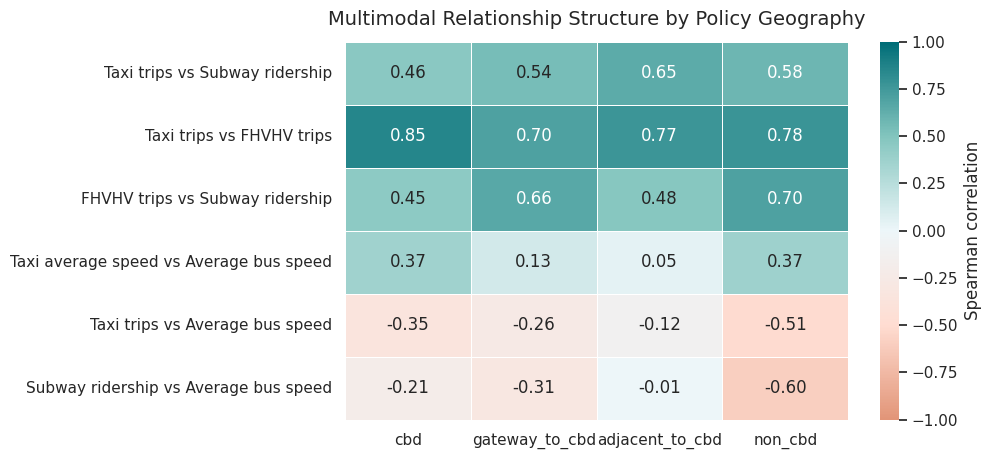

In [16]:
# ---------------------------------------------------------------------
# Compare multimodal relationships across broad geography cuts
# ---------------------------------------------------------------------

broad_geo_relationship_records = []

for pair_type, metric_x, metric_y in PRIMARY_PAIR_DEFINITIONS:
    pair_label = f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}"

    for geography_group in POLICY_GEOGRAPHY_ORDER:
        pair_slice_df = zone_daily_wide_df.loc[
            zone_daily_wide_df["cbd_spatial_category"] == geography_group,
            ["taxi_zone_id", "date", metric_x, metric_y],
        ].dropna()

        broad_geo_relationship_records.append(
            {
                "pair_type": pair_type,
                "pair_label": pair_label,
                "cbd_spatial_category": geography_group,
                "spearman_correlation": (
                    pair_slice_df[metric_x].corr(pair_slice_df[metric_y], method="spearman")
                    if len(pair_slice_df) > 50 else np.nan
                ),
                "matched_zone_days": len(pair_slice_df),
                "distinct_zones": pair_slice_df["taxi_zone_id"].nunique(),
            }
        )

broad_geo_relationship_df = pd.DataFrame(broad_geo_relationship_records)

broad_geo_relationship_heatmap_df = (
    broad_geo_relationship_df
    .pivot(index="pair_label", columns="cbd_spatial_category", values="spearman_correlation")
    .reindex(
        index=[
            f"{METRIC_LABELS[x]} vs {METRIC_LABELS[y]}"
            for _, x, y in PRIMARY_PAIR_DEFINITIONS
        ],
        columns=POLICY_GEOGRAPHY_ORDER,
    )
    .round(3)
)

plt.figure(figsize=(10, 4.75))
sns.heatmap(
    broad_geo_relationship_heatmap_df,
    annot=True,
    fmt=".2f",
    cmap=BRAND_DIVERGING_CMAP.reversed(),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"},
)
plt.title("Multimodal Relationship Structure by Policy Geography", fontsize=14, pad=12)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        OUTPUT_DIR / "1.4.2.4_policy_geography_relationship_heatmap.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

This table makes the geography split easier to read without scanning the heatmap cell by cell\. It also keeps the sample sizes visible so we can tell whether a pattern is broad or sitting on thin support\.

In [17]:
# ---------------------------------------------------------------------
# Summarize multimodal relationships across broad geography cuts
# ---------------------------------------------------------------------

display(
    broad_geo_relationship_df[
        [
            "pair_label",
            "cbd_spatial_category",
            "spearman_correlation",
            "matched_zone_days",
            "distinct_zones",
        ]
    ]
    .sort_values(["pair_label", "cbd_spatial_category"])
    .round(3)
    .reset_index(drop=True)
)

,pair_label,cbd_spatial_category,spearman_correlation,matched_zone_days,distinct_zones
0,FHVHV trips vs Subway ridership,adjacent_to_cbd,0.481,8302,7
1,FHVHV trips vs Subway ridership,cbd,0.449,48626,41
2,FHVHV trips vs Subway ridership,gateway_to_cbd,0.662,14232,12
3,FHVHV trips vs Subway ridership,non_cbd,0.697,238386,201
4,Subway ridership vs Average bus speed,adjacent_to_cbd,-0.007,8302,7
5,Subway ridership vs Average bus speed,cbd,-0.207,44729,38
6,Subway ridership vs Average bus speed,gateway_to_cbd,-0.309,12707,11
7,Subway ridership vs Average bus speed,non_cbd,-0.597,231499,196
8,Taxi average speed vs Average bus speed,adjacent_to_cbd,0.046,8302,7
9,Taxi average speed vs Average bus speed,cbd,0.366,44715,38


Findings\. The broad geography split shows that the citywide multimodal relationships do not hold equally across space\. Taxi trips and FHVHV trips remain strongly aligned everywhere, but that relationship is especially strong inside the CBD and somewhat weaker in gateway areas\. Taxi trips and Subway ridership are also positively related across all four geography groups, though that link is strongest in adjacent\-to\-CBD areas and weakest in the CBD itself\. FHVHV trips and Subway ridership show an even sharper geography pattern: the relationship is only moderate in CBD and adjacent zones, but becomes much stronger in gateway and especially non\-CBD areas\. The demand\-versus\-speed pairs vary the most\. Taxi trips versus Average bus speed and Subway ridership versus Average bus speed are both much more strongly negative in non\-CBD areas, while those relationships are weak to nearly absent in adjacent\-to\-CBD zones\. Taxi average speed versus Average bus speed stays positive everywhere, but is much weaker in gateway and adjacent areas than in the CBD or non\-CBD parts of the city\. Overall, the main takeaway is that spatial context clearly changes how the modes relate, especially for the pairs involving bus speed, so the citywide averages are smoothing over meaningful geographic differences\.

This follow\-up asks a narrower question than the broad geography heatmap\. Instead of averaging across groups of zones, we look at each Taxi Zone separately and ask how tightly Taxi trips and Subway ridership move together over time within that zone\. We then compare which zones show the strongest within\-zone Taxi/Subway relationship before congestion pricing and which zones show the strongest relationship after, so we can tell whether the same places stay prominent or whether that local relationship shifts geographically\.

In [18]:
# ---------------------------------------------------------------------
# Compare standout zones before and after congestion pricing for one focal pair
# ---------------------------------------------------------------------

focal_spatial_pair = ("taxi_trip_count", "subway_ridership")
focal_pair_label = f"{METRIC_LABELS[focal_spatial_pair[0]]} vs {METRIC_LABELS[focal_spatial_pair[1]]}"

zone_regime_relationship_records = []

for regime_label in ["pre_cp", "post_cp"]:
    for zone_id in zone_daily_wide_df["taxi_zone_id"].dropna().unique():
        zone_slice_df = zone_daily_wide_df.loc[
            (zone_daily_wide_df["taxi_zone_id"] == zone_id)
            & (zone_daily_wide_df["pre_post_cp"] == regime_label),
            ["taxi_zone_id", "zone", "borough", focal_spatial_pair[0], focal_spatial_pair[1]],
        ].dropna()

        if zone_slice_df.empty:
            continue

        x_unique = zone_slice_df[focal_spatial_pair[0]].nunique()
        y_unique = zone_slice_df[focal_spatial_pair[1]].nunique()

        if len(zone_slice_df) < 60 or x_unique <= 1 or y_unique <= 1:
            continue

        zone_meta = zone_slice_df[["taxi_zone_id", "zone", "borough"]].iloc[0]

        zone_regime_relationship_records.append(
            {
                "taxi_zone_id": zone_meta["taxi_zone_id"],
                "zone": zone_meta["zone"],
                "borough": zone_meta["borough"],
                "policy_regime": regime_label,
                "spearman_correlation": zone_slice_df[focal_spatial_pair[0]].corr(
                    zone_slice_df[focal_spatial_pair[1]],
                    method="spearman",
                ),
                "matched_rows": len(zone_slice_df),
            }
        )

zone_regime_relationship_df = pd.DataFrame(zone_regime_relationship_records)

zone_regime_rank_df = (
    zone_regime_relationship_df.assign(
        abs_spearman_correlation=lambda df: df["spearman_correlation"].abs()
    )
    .pivot(
        index=["taxi_zone_id", "zone", "borough"],
        columns="policy_regime",
        values=["spearman_correlation", "abs_spearman_correlation", "matched_rows"],
    )
)

zone_regime_rank_df.columns = [
    f"{value}_{regime}" for value, regime in zone_regime_rank_df.columns
]
zone_regime_rank_df = zone_regime_rank_df.reset_index()

zone_regime_rank_df["pre_rank"] = (
    zone_regime_rank_df["abs_spearman_correlation_pre_cp"]
    .rank(ascending=False, method="min")
)
zone_regime_rank_df["post_rank"] = (
    zone_regime_rank_df["abs_spearman_correlation_post_cp"]
    .rank(ascending=False, method="min")
)
zone_regime_rank_df["rank_shift"] = (
    zone_regime_rank_df["post_rank"] - zone_regime_rank_df["pre_rank"]
)
zone_regime_rank_df["correlation_shift"] = (
    zone_regime_rank_df["spearman_correlation_post_cp"]
    - zone_regime_rank_df["spearman_correlation_pre_cp"]
)

standout_zone_regime_comparison_df = (
    zone_regime_rank_df.loc[
        (zone_regime_rank_df["pre_rank"] <= 12)
        | (zone_regime_rank_df["post_rank"] <= 12)
    ]
    .sort_values(["post_rank", "pre_rank"])
    .round(3)
    .reset_index(drop=True)
)

display(
    standout_zone_regime_comparison_df[
        [
            "zone",
            "borough",
            "spearman_correlation_pre_cp",
            "spearman_correlation_post_cp",
            "pre_rank",
            "post_rank",
            "rank_shift",
            "correlation_shift",
        ]
    ]
)

,zone,borough,spearman_correlation_pre_cp,spearman_correlation_post_cp,pre_rank,post_rank,rank_shift,correlation_shift
0,Midtown East,Manhattan,0.888,0.902,1.0,1.0,0.0,0.015
1,Upper East Side North,Manhattan,0.880,0.884,2.0,2.0,0.0,0.004
2,Upper East Side South,Manhattan,0.865,0.859,3.0,3.0,0.0,-0.006
3,Midtown North,Manhattan,0.798,0.850,7.0,4.0,-3.0,0.052
4,East Harlem South,Manhattan,0.838,0.818,5.0,5.0,0.0,-0.020
5,Midtown Center,Manhattan,0.859,0.815,4.0,6.0,2.0,-0.044
6,Lincoln Square West,Manhattan,0.808,0.797,6.0,7.0,1.0,-0.011
7,Garment District,Manhattan,0.731,0.765,9.0,8.0,-1.0,0.034
8,Upper West Side North,Manhattan,0.737,0.761,8.0,9.0,1.0,0.024
9,Morningside Heights,Manhattan,0.678,0.623,11.0,10.0,-1.0,-0.055


Findings\. The strongest local Taxi/Subway relationships remain concentrated in the same Manhattan core before and after congestion pricing\. Midtown East, the Upper East Side, Midtown North, and nearby zones stay at the top in both periods, with only modest reshuffling among the leaders\. That means the geography of this particular multimodal relationship is mostly persistent rather than fully re\-sorted after the policy change\. The main exception is East Chelsea, which jumps from essentially no local Taxi/Subway relationship before congestion pricing to one of the strongest post\-period zones\. Kew Gardens moves in the opposite direction, falling off sharply in both rank and strength\. So the overall pattern is stable at the top, but a few zones do show meaningful local change\.

### Review selected high\-interest zones through a multimodal lens

Now let’s zoom in on the eight high\-interest zones we already picked\. The point here is not to prove that every zone is unique, but to see whether a few concrete local mobility systems show relationship structure that looks materially different from the citywide picture\.

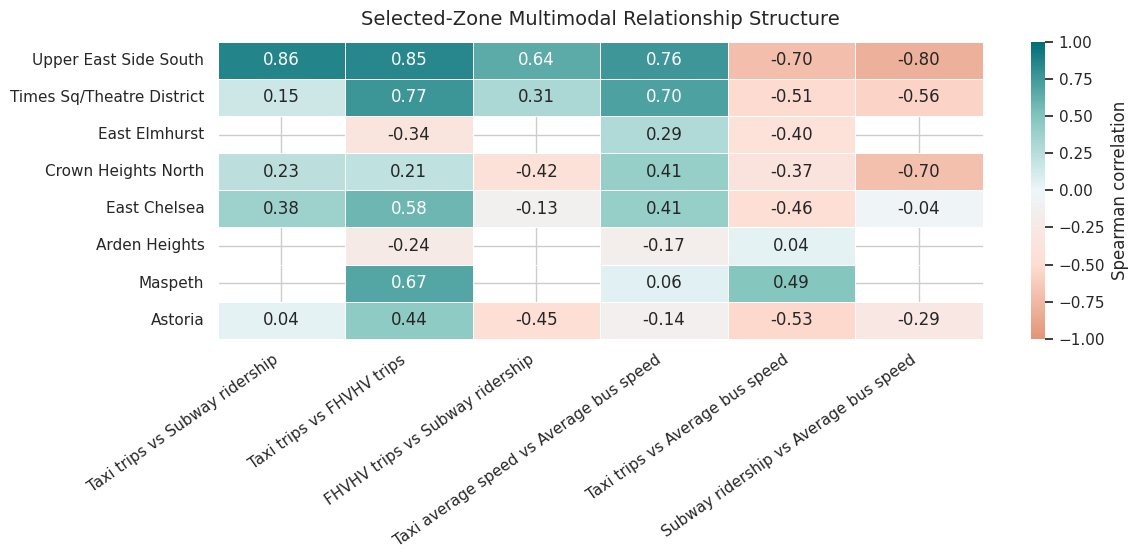

In [19]:
# ---------------------------------------------------------------------
# Review selected high-interest zones through a multimodal lens
# ---------------------------------------------------------------------

selected_zone_relationship_records = []

for _, zone_row in selected_zone_reference_df.iterrows():
    zone_id = zone_row["taxi_zone_id"]
    zone_name = zone_row["zone"]

    zone_df = zone_daily_wide_df.loc[
        zone_daily_wide_df["taxi_zone_id"] == zone_id
    ].copy()

    for pair_type, metric_x, metric_y in PRIMARY_PAIR_DEFINITIONS:
        pair_label = f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}"
        pair_slice_df = zone_df[[metric_x, metric_y]].dropna()

        if len(pair_slice_df) <= 100:
            continue

        x_unique = pair_slice_df[metric_x].nunique()
        y_unique = pair_slice_df[metric_y].nunique()

        if x_unique <= 1 or y_unique <= 1:
            continue

        selected_zone_relationship_records.append(
            {
                "taxi_zone_id": zone_id,
                "zone": zone_name,
                "selection_reason": zone_row["selection_reason"],
                "pair_type": pair_type,
                "pair_label": pair_label,
                "spearman_correlation": pair_slice_df[metric_x].corr(
                    pair_slice_df[metric_y],
                    method="spearman",
                ),
                "matched_days": len(pair_slice_df),
            }
        )

selected_zone_relationship_df = pd.DataFrame(selected_zone_relationship_records)

selected_zone_relationship_heatmap_df = (
    selected_zone_relationship_df
    .pivot(index="zone", columns="pair_label", values="spearman_correlation")
    .reindex(
        index=selected_zone_reference_df["zone"].tolist(),
        columns=[
            f"{METRIC_LABELS[x]} vs {METRIC_LABELS[y]}"
            for _, x, y in PRIMARY_PAIR_DEFINITIONS
        ],
    )
    .round(3)
)

plt.figure(figsize=(12, 5.75))
sns.heatmap(
    selected_zone_relationship_heatmap_df,
    annot=True,
    fmt=".2f",
    cmap=BRAND_DIVERGING_CMAP.reversed(),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"},
)
plt.title("Selected-Zone Multimodal Relationship Structure", fontsize=14, pad=12)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        OUTPUT_DIR / "1.4.2.4_selected_zone_relationship_heatmap.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

A compact table helps surface which selected zones are most aligned or most off\-pattern for each pair\. That makes it easier to talk about local exceptions without overloading the heatmap itself\.

In [20]:
# ---------------------------------------------------------------------
# Summarize selected-zone relationship structure
# ---------------------------------------------------------------------

display(
    selected_zone_relationship_df[
        [
            "zone",
            "selection_reason",
            "pair_label",
            "spearman_correlation",
            "matched_days",
        ]
    ]
    .sort_values(["pair_label", "spearman_correlation"], ascending=[True, False])
    .round(3)
    .reset_index(drop=True)
)

,zone,selection_reason,pair_label,spearman_correlation,matched_days
0,Upper East Side South,manhattan_taxi_anchor,FHVHV trips vs Subway ridership,0.643,1186
1,Times Sq/Theatre District,manhattan_subway_anchor,FHVHV trips vs Subway ridership,0.306,1186
2,East Chelsea,strongest_positive_shift,FHVHV trips vs Subway ridership,-0.129,1186
3,Crown Heights North,outer_borough_fhvhv_anchor,FHVHV trips vs Subway ridership,-0.421,1186
4,Astoria,outer_borough_balanced_contrast,FHVHV trips vs Subway ridership,-0.447,1186
5,East Chelsea,strongest_positive_shift,Subway ridership vs Average bus speed,-0.043,1186
6,Astoria,outer_borough_balanced_contrast,Subway ridership vs Average bus speed,-0.295,1186
7,Times Sq/Theatre District,manhattan_subway_anchor,Subway ridership vs Average bus speed,-0.558,1186
8,Crown Heights North,outer_borough_fhvhv_anchor,Subway ridership vs Average bus speed,-0.702,1186
9,Upper East Side South,manhattan_taxi_anchor,Subway ridership vs Average bus speed,-0.804,1186


Findings\. The zone\-level multimodal picture is much more uneven than the citywide summaries suggest\. Upper East Side South stands out as the most tightly integrated zone across modes, with very strong positive alignment between Taxi trips, FHVHV trips, and Subway ridership, plus a strong positive link between Taxi and Bus speeds and strong inverse relationships between demand and Bus speed\. Times Square/Theatre District is also strongly connected, but with a weaker Taxi trips–Subway relationship than Upper East Side South\. Outside those Manhattan anchors, the structure becomes much more mixed: Crown Heights North and Astoria show negative FHVHV trips–Subway relationships, East Elmhurst and Arden Heights weaken or even flip some of the usual Taxi/FHVHV patterns, and Maspeth shows unusually weak Taxi speed–Bus speed coupling alongside a positive Taxi trips–Bus speed relationship\. So the big takeaway is that local mobility systems are behaving quite differently from one another, which is exactly why later modeling and the app should keep respecting zone\-level structure instead of leaning too hard on citywide averages\.

### Identify where citywide relationship summaries hide local variation

The last step is to test directly whether the citywide relationship summaries are smoothing over meaningful zone\-level spread\. This is where we compare the citywide relationship values with the actual distribution of zone\-level correlations across the whole city\.

In [21]:
# ---------------------------------------------------------------------
# Identify where citywide relationship summaries hide local variation
# ---------------------------------------------------------------------

zone_pair_relationship_records = []

for pair_type, metric_x, metric_y in PRIMARY_PAIR_DEFINITIONS:
    pair_label = f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}"

    for zone_id, zone_df in zone_daily_wide_df.groupby("taxi_zone_id"):
        pair_slice_df = zone_df[
            ["zone", "borough", "cbd_spatial_category", metric_x, metric_y]
        ].dropna()

        if len(pair_slice_df) <= 100:
            continue

        x_unique = pair_slice_df[metric_x].nunique()
        y_unique = pair_slice_df[metric_y].nunique()

        if x_unique <= 1 or y_unique <= 1:
            continue

        zone_pair_relationship_records.append(
            {
                "taxi_zone_id": zone_id,
                "zone": pair_slice_df["zone"].iloc[0],
                "borough": pair_slice_df["borough"].iloc[0],
                "cbd_spatial_category": pair_slice_df["cbd_spatial_category"].iloc[0],
                "pair_label": pair_label,
                "spearman_correlation": pair_slice_df[metric_x].corr(
                    pair_slice_df[metric_y],
                    method="spearman",
                ),
                "matched_days": len(pair_slice_df),
            }
        )

zone_pair_relationship_df = pd.DataFrame(zone_pair_relationship_records)

citywide_pair_relationship_df = (
    pairwise_relationship_summary_df.loc[
        pairwise_relationship_summary_df["period"] == "full_period",
        ["pair_label", "spearman_correlation"]
    ]
    .rename(columns={"spearman_correlation": "citywide_spearman_correlation"})
)

zone_relationship_spread_summary_df = (
    zone_pair_relationship_df
    .groupby("pair_label", as_index=False)
    .agg(
        eligible_zone_count=("taxi_zone_id", "nunique"),
        zone_p10_correlation=("spearman_correlation", lambda s: s.quantile(0.10)),
        zone_p50_correlation=("spearman_correlation", "median"),
        zone_p90_correlation=("spearman_correlation", lambda s: s.quantile(0.90)),
        zone_std_correlation=("spearman_correlation", "std"),
    )
    .merge(citywide_pair_relationship_df, on="pair_label", how="left")
    .round(3)
)

display(
    zone_relationship_spread_summary_df[
        [
            "pair_label",
            "citywide_spearman_correlation",
            "eligible_zone_count",
            "zone_p10_correlation",
            "zone_p50_correlation",
            "zone_p90_correlation",
            "zone_std_correlation",
        ]
    ]
    .sort_values("pair_label")
    .reset_index(drop=True)
)

,pair_label,citywide_spearman_correlation,eligible_zone_count,zone_p10_correlation,zone_p50_correlation,zone_p90_correlation,zone_std_correlation
0,FHVHV trips vs Subway ridership,-0.079,156,-0.317,0.039,0.450,0.291
1,Subway ridership vs Average bus speed,-0.698,155,-0.723,-0.566,-0.116,0.274
2,Taxi average speed vs Average bus speed,0.693,247,0.025,0.286,0.548,0.207
3,Taxi trips vs Average bus speed,-0.287,252,-0.463,-0.139,0.200,0.268
4,Taxi trips vs FHVHV trips,0.576,261,0.187,0.450,0.705,0.202
5,Taxi trips vs Subway ridership,0.567,156,0.049,0.271,0.542,0.222


This visual makes the smoothing problem easier to see\. Each panel shows the spread of zone\-level correlations for one multimodal pair, with the citywide summary drawn as a reference line\.

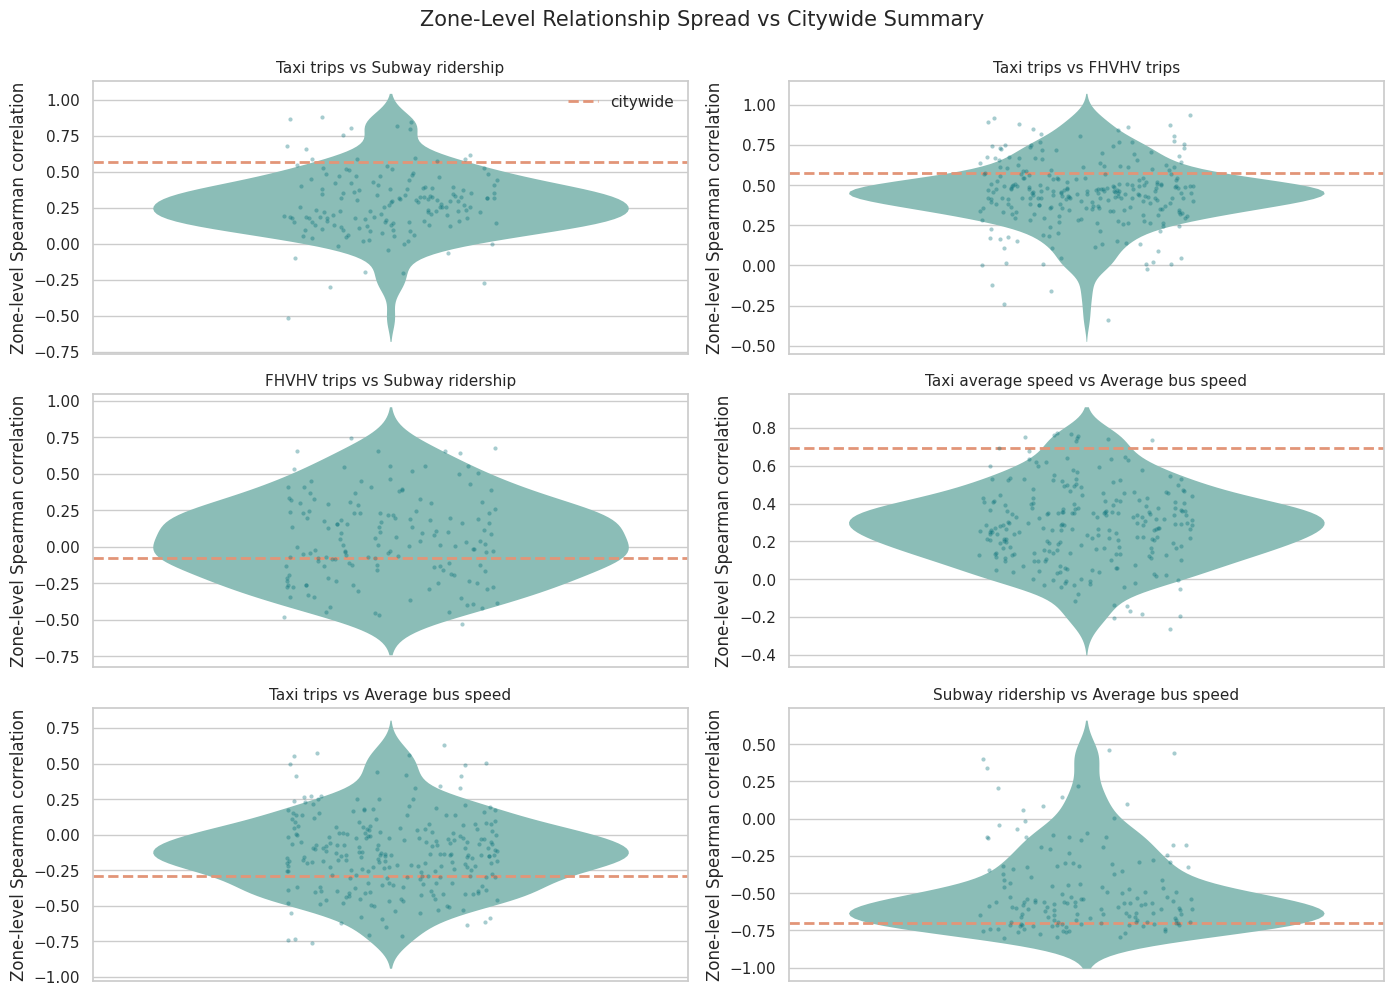

In [22]:
# ---------------------------------------------------------------------
# Visualize zone-level relationship spread against the citywide summary
# ---------------------------------------------------------------------

pair_order = [
    f"{METRIC_LABELS[x]} vs {METRIC_LABELS[y]}"
    for _, x, y in PRIMARY_PAIR_DEFINITIONS
]

citywide_relationship_lookup = citywide_pair_relationship_df.set_index("pair_label")[
    "citywide_spearman_correlation"
].to_dict()

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, pair_label in zip(axes, pair_order):
    pair_df = zone_pair_relationship_df.loc[
        zone_pair_relationship_df["pair_label"] == pair_label
    ].copy()

    sns.violinplot(
        data=pair_df,
        y="spearman_correlation",
        color=BRAND_COLORS["seafoam"],
        inner=None,
        linewidth=0,
        ax=ax,
    )
    sns.stripplot(
        data=pair_df,
        y="spearman_correlation",
        color=BRAND_COLORS["dark_teal"],
        alpha=0.35,
        size=3,
        jitter=0.18,
        ax=ax,
    )

    ax.axhline(
        citywide_relationship_lookup[pair_label],
        color=BRAND_COLORS["terracotta"],
        linestyle="--",
        linewidth=2,
        label="citywide",
    )

    ax.set_title(pair_label, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Zone-level Spearman correlation")
    ax.set_xticks([])

axes[0].legend(frameon=False, loc="upper right")
fig.suptitle("Zone-Level Relationship Spread vs Citywide Summary", fontsize=15, y=0.995)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        OUTPUT_DIR / "1.4.2.4_zone_relationship_spread.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. This view makes the same point pretty forcefully: citywide relationship summaries are often hiding a lot of local heterogeneity\. Some pairs stay directionally consistent but vary a lot in strength across zones, like Taxi trips vs FHVHV trips and Taxi trips vs Subway ridership, where the citywide positive relationship is real but much stronger in some places than others\. Other pairs are even less stable spatially\. FHVHV trips vs Subway ridership is basically near\-zero at the citywide level, but the zone distribution spans clearly negative to clearly positive relationships, which means the aggregate is washing out very different local stories\. Taxi trips vs Average bus speed also crosses zero across zones, so the weak citywide negative relationship is really an average over both inverse and same\-direction local patterns\. Even the more stable pairs, like Subway ridership vs Average bus speed and Taxi average speed vs Average bus speed, still show meaningful spread around the citywide line\. So the main takeaway is that citywide correlations are useful as a first pass, but they are not a reliable substitute for zone\-level relationship structure\.

## 1\.4\.2\.5 Contextual explanations for multimodal divergences

This section only looks at a few divergence cases that already stood out earlier in the notebook\. The point is to ask a simple question: when a multimodal relationship looks unusually weak or unusually out of character, do the contextual layers help explain why?

### Identify the most important multimodal divergence cases to review

We start by selecting a small number of relationship\-break windows from the strongest multimodal pairings we already focused on earlier\. These are rolling windows where the relationship drops well below its usual level for that pair, which gives us a short list of cases worth checking against contextual signals\.

In [23]:
# ---------------------------------------------------------------------
# Identify the most important multimodal divergence cases to review
# ---------------------------------------------------------------------

CONTEXT_CASE_PAIR_DEFINITIONS = [
    ("taxi_trip_count", "subway_ridership"),
    ("taxi_trip_count", "fhvhv_trip_count"),
]

CASE_WINDOW_DAYS = 60
CASE_STEP_DAYS = 14
CASE_MIN_MATCHED_DAYS = 40
CASE_SEPARATION_DAYS = 45
TOP_CASES_PER_PAIR = 2

context_case_records = []

for metric_x, metric_y in CONTEXT_CASE_PAIR_DEFINITIONS:
    pair_label = f"{METRIC_LABELS[metric_x]} vs {METRIC_LABELS[metric_y]}"

    pair_df = (
        citywide_daily_wide_df[["date", "pre_post_cp", metric_x, metric_y]]
        .dropna()
        .sort_values("date")
        .reset_index(drop=True)
    )

    if pair_df.empty:
        continue

    window_start = pair_df["date"].min()
    window_limit = pair_df["date"].max()

    rolling_records = []

    while window_start + pd.Timedelta(days=CASE_WINDOW_DAYS - 1) <= window_limit:
        window_end = window_start + pd.Timedelta(days=CASE_WINDOW_DAYS - 1)

        window_slice_df = pair_df.loc[
            pair_df["date"].between(window_start, window_end),
            ["date", metric_x, metric_y],
        ].dropna()

        x_unique = window_slice_df[metric_x].nunique()
        y_unique = window_slice_df[metric_y].nunique()

        rolling_corr = (
            window_slice_df[metric_x].corr(window_slice_df[metric_y], method="spearman")
            if len(window_slice_df) >= CASE_MIN_MATCHED_DAYS and x_unique > 1 and y_unique > 1
            else np.nan
        )

        rolling_records.append(
            {
                "pair_label": pair_label,
                "metric_x": metric_x,
                "metric_y": metric_y,
                "window_start": window_start,
                "window_end": window_end,
                "window_midpoint": window_start + pd.Timedelta(days=CASE_WINDOW_DAYS // 2),
                "rolling_spearman_correlation": rolling_corr,
                "matched_days": len(window_slice_df),
            }
        )

        window_start = window_start + pd.Timedelta(days=CASE_STEP_DAYS)

    pair_case_df = pd.DataFrame(rolling_records).dropna(
        subset=["rolling_spearman_correlation"]
    ).copy()

    if pair_case_df.empty:
        continue

    pair_case_df["pair_median_correlation"] = pair_case_df["rolling_spearman_correlation"].median()
    pair_case_df["correlation_drop_vs_pair_median"] = (
        pair_case_df["rolling_spearman_correlation"] - pair_case_df["pair_median_correlation"]
    )

    pair_case_df = pair_case_df.sort_values("correlation_drop_vs_pair_median")

    selected_rows = []
    selected_midpoints = []

    for _, row in pair_case_df.iterrows():
        midpoint = row["window_midpoint"]

        if any(abs((midpoint - existing_midpoint).days) < CASE_SEPARATION_DAYS for existing_midpoint in selected_midpoints):
            continue

        selected_rows.append(row.to_dict())
        selected_midpoints.append(midpoint)

        if len(selected_rows) >= TOP_CASES_PER_PAIR:
            break

    context_case_records.extend(selected_rows)

divergence_case_summary_df = (
    pd.DataFrame(context_case_records)
    .sort_values(["correlation_drop_vs_pair_median", "window_midpoint"])
    .reset_index(drop=True)
)

divergence_case_summary_df["case_id"] = [
    f"case_{i+1}" for i in range(len(divergence_case_summary_df))
]

display(
    divergence_case_summary_df[
        [
            "case_id",
            "pair_label",
            "window_start",
            "window_end",
            "rolling_spearman_correlation",
            "pair_median_correlation",
            "correlation_drop_vs_pair_median",
            "matched_days",
        ]
    ].round(3)
)

,case_id,pair_label,window_start,window_end,rolling_spearman_correlation,pair_median_correlation,correlation_drop_vs_pair_median,matched_days
0,case_1,Taxi trips vs FHVHV trips,2023-07-30,2023-09-27,0.107,0.647,-0.540,60
1,case_2,Taxi trips vs FHVHV trips,2024-07-14,2024-09-11,0.293,0.647,-0.354,60
2,case_3,Taxi trips vs Subway ridership,2025-03-09,2025-05-07,0.228,0.542,-0.314,60
3,case_4,Taxi trips vs Subway ridership,2025-09-07,2025-11-05,0.298,0.542,-0.244,60


Findings\. The clearest relationship\-break cases are pretty concentrated\. For Taxi trips vs FHVHV trips, the sharpest divergence window is late summer 2023, when the rolling relationship drops far below its usual level, with another weaker break in late summer 2024\. For Taxi trips vs Subway ridership, the biggest break shows up in spring 2025, followed by another smaller weakening in fall 2025\. So the main pattern is not a long list of scattered breaks, but a short set of specific windows where otherwise strong multimodal relationships temporarily came apart enough to be worth explaining\.

### Compare divergence cases against Weather and Bridge/Tunnel context

Now we take those case windows and compare them against whatever contextual signals are actually available in the harmonized Weather and Bridge/Tunnel tables\. This block is intentionally schema\-aware so it uses the real upstream columns instead of assuming a fixed context layout\. For each case, it pulls the strongest weather\-style and bridge/tunnel\-style contextual deviation and tells us whether the divergence window also looks context\-heavy\.

In [24]:
# ---------------------------------------------------------------------
# Compare divergence cases against Weather and Bridge/Tunnel context
# ---------------------------------------------------------------------

def describe_parquet_columns(parquet_path: Path) -> list[str]:
    schema_df = con.execute(
        f"DESCRIBE SELECT * FROM read_parquet('{parquet_path.as_posix()}')"
    ).df()
    return schema_df["column_name"].tolist()

def first_present(columns, candidates):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None

context_daily_frames = []
context_metric_roles = []

# Weather context
if WEATHER_CONTEXT_PATH.exists():
    weather_columns = describe_parquet_columns(WEATHER_CONTEXT_PATH)

    weather_role_lookup = {
        "weather_precipitation": [
            "precipitation",
            "weather_precipitation",
            "daily_precipitation",
        ],
        "weather_visibility": [
            "visibility",
            "weather_visibility",
            "daily_visibility",
        ],
        "weather_wind_speed": [
            "wind_speed",
            "weather_wind_speed",
            "daily_wind_speed",
        ],
        "weather_temperature": [
            "temperature",
            "weather_temperature",
            "daily_temperature",
        ],
    }

    weather_selected = {
        role: first_present(weather_columns, candidates)
        for role, candidates in weather_role_lookup.items()
    }

    weather_agg_exprs = []
    for role, source_col in weather_selected.items():
        if source_col is None:
            continue

        if role == "weather_precipitation":
            agg_expr = f"MAX({source_col}) AS {role}"
        elif role == "weather_visibility":
            agg_expr = f"MIN({source_col}) AS {role}"
        elif role == "weather_wind_speed":
            agg_expr = f"MAX({source_col}) AS {role}"
        else:
            agg_expr = f"AVG({source_col}) AS {role}"

        weather_agg_exprs.append(agg_expr)
        context_metric_roles.append({"context_metric": role, "context_family": "weather"})

    if weather_agg_exprs:
        weather_daily_context_df = con.execute(
            f"""
            SELECT
                CAST(date AS DATE) AS date,
                {", ".join(weather_agg_exprs)}
            FROM read_parquet('{WEATHER_CONTEXT_PATH.as_posix()}')
            GROUP BY 1
            ORDER BY 1
            """
        ).df()

        context_daily_frames.append(weather_daily_context_df)

# Bridge/Tunnel context
if BRIDGE_TUNNEL_CONTEXT_PATH.exists():
    bridge_columns = describe_parquet_columns(BRIDGE_TUNNEL_CONTEXT_PATH)

    bridge_numeric_candidates = [
        col for col in bridge_columns
        if col.lower() not in {
            "date",
            "temporal_bucket",
            "pre_post_cp",
            "day_of_week",
            "direction",
            "facility",
            "facility_name",
            "year",
            "month",
            "daypart",
            "temporal_bucket_order",
            "observation_sequence_id",
        }
    ]

    preferred_bridge_cols = [
        col for col in bridge_numeric_candidates
        if any(token in col.lower() for token in ["count", "volume", "flow", "traffic", "trip", "vehicle"])
    ]

    selected_bridge_cols = preferred_bridge_cols[:3] if preferred_bridge_cols else bridge_numeric_candidates[:3]

    bridge_agg_exprs = []
    for source_col in selected_bridge_cols:
        role = f"bridge_{source_col}"
        if any(token in source_col.lower() for token in ["count", "volume", "flow", "traffic", "trip", "vehicle"]):
            agg_expr = f"SUM({source_col}) AS {role}"
        else:
            agg_expr = f"AVG({source_col}) AS {role}"

        bridge_agg_exprs.append(agg_expr)
        context_metric_roles.append({"context_metric": role, "context_family": "bridge_tunnel"})

    if bridge_agg_exprs:
        bridge_daily_context_df = con.execute(
            f"""
            SELECT
                CAST(date AS DATE) AS date,
                {", ".join(bridge_agg_exprs)}
            FROM read_parquet('{BRIDGE_TUNNEL_CONTEXT_PATH.as_posix()}')
            GROUP BY 1
            ORDER BY 1
            """
        ).df()

        context_daily_frames.append(bridge_daily_context_df)

if context_daily_frames:
    context_daily_df = context_daily_frames[0].copy()

    for next_df in context_daily_frames[1:]:
        context_daily_df = context_daily_df.merge(next_df, on="date", how="outer")

    context_daily_df = context_daily_df.sort_values("date").reset_index(drop=True)

    context_metric_role_df = pd.DataFrame(context_metric_roles).drop_duplicates()

    context_metric_columns = [
        col for col in context_daily_df.columns
        if col != "date"
    ]

    for col in context_metric_columns:
        series = context_daily_df[col]
        std_value = series.std()

        if pd.notna(std_value) and std_value > 0:
            context_daily_df[f"{col}__z"] = (series - series.mean()) / std_value
        else:
            context_daily_df[f"{col}__z"] = np.nan

    divergence_context_records = []

    for _, case_row in divergence_case_summary_df.iterrows():
        case_window_df = context_daily_df.loc[
            context_daily_df["date"].between(case_row["window_start"], case_row["window_end"])
        ].copy()

        if case_window_df.empty:
            continue

        context_summary_rows = []

        for context_metric in context_metric_columns:
            z_col = f"{context_metric}__z"
            if z_col not in case_window_df.columns:
                continue

            z_mean = case_window_df[z_col].mean()

            context_summary_rows.append(
                {
                    "context_metric": context_metric,
                    "mean_case_zscore": z_mean,
                    "abs_mean_case_zscore": abs(z_mean) if pd.notna(z_mean) else np.nan,
                }
            )

        if not context_summary_rows:
            continue

        context_case_metric_df = (
            pd.DataFrame(context_summary_rows)
            .merge(context_metric_role_df, on="context_metric", how="left")
            .sort_values("abs_mean_case_zscore", ascending=False)
        )

        top_weather_row = context_case_metric_df.loc[
            context_case_metric_df["context_family"] == "weather"
        ].head(1)

        top_bridge_row = context_case_metric_df.loc[
            context_case_metric_df["context_family"] == "bridge_tunnel"
        ].head(1)

        divergence_context_records.append(
            {
                "case_id": case_row["case_id"],
                "pair_label": case_row["pair_label"],
                "window_start": case_row["window_start"],
                "window_end": case_row["window_end"],
                "rolling_spearman_correlation": case_row["rolling_spearman_correlation"],
                "correlation_drop_vs_pair_median": case_row["correlation_drop_vs_pair_median"],
                "top_weather_context_metric": (
                    top_weather_row["context_metric"].iloc[0] if not top_weather_row.empty else np.nan
                ),
                "top_weather_context_z": (
                    top_weather_row["mean_case_zscore"].iloc[0] if not top_weather_row.empty else np.nan
                ),
                "top_bridge_context_metric": (
                    top_bridge_row["context_metric"].iloc[0] if not top_bridge_row.empty else np.nan
                ),
                "top_bridge_context_z": (
                    top_bridge_row["mean_case_zscore"].iloc[0] if not top_bridge_row.empty else np.nan
                ),
            }
        )

    divergence_context_summary_df = (
        pd.DataFrame(divergence_context_records)
        .round(3)
        .sort_values(["correlation_drop_vs_pair_median", "case_id"])
        .reset_index(drop=True)
    )

    display(divergence_context_summary_df)

else:
    divergence_context_summary_df = pd.DataFrame(
        {
            "note": [
                "No usable Weather or Bridge/Tunnel context columns were available for case comparison."
            ]
        }
    )
    display(divergence_context_summary_df)

,case_id,pair_label,window_start,window_end,rolling_spearman_correlation,correlation_drop_vs_pair_median,top_weather_context_metric,top_weather_context_z,top_bridge_context_metric,top_bridge_context_z
0,case_1,Taxi trips vs FHVHV trips,2023-07-30,2023-09-27,0.107,-0.540,weather_temperature,1.065,bridge_bridge_tunnel_volume,0.367
1,case_2,Taxi trips vs FHVHV trips,2024-07-14,2024-09-11,0.293,-0.354,weather_temperature,1.205,bridge_bridge_tunnel_volume,0.428
2,case_3,Taxi trips vs Subway ridership,2025-03-09,2025-05-07,0.228,-0.314,weather_wind_speed,0.392,bridge_bridge_tunnel_volume,0.160
3,case_4,Taxi trips vs Subway ridership,2025-09-07,2025-11-05,0.298,-0.244,weather_temperature,0.456,bridge_bridge_tunnel_volume,0.373


Findings\. The contextual layers add a little interpretive help here, but not a dramatic explanation\. Both of the Taxi trips vs FHVHV trips break windows line up most strongly with warmer\-than\-usual weather, while Bridge/Tunnel volume only shows a mild positive signal\. The two Taxi trips vs Subway ridership break windows have even weaker context, with only modest wind or temperature deviation and fairly small Bridge/Tunnel movement\. So the overall read is that Weather and Bridge/Tunnel can sometimes add a bit of texture around these divergence windows, but they do not look strong enough here to explain the breaks on their own\.

This last view is just a spot check\. For the cases where contextual signals look strongest, we line up the two mobility series with the single strongest contextual signal in the same window\. The goal is not to prove causality\. It is just to see whether the divergence case and the contextual spike actually sit on top of each other in a way that feels informative\.

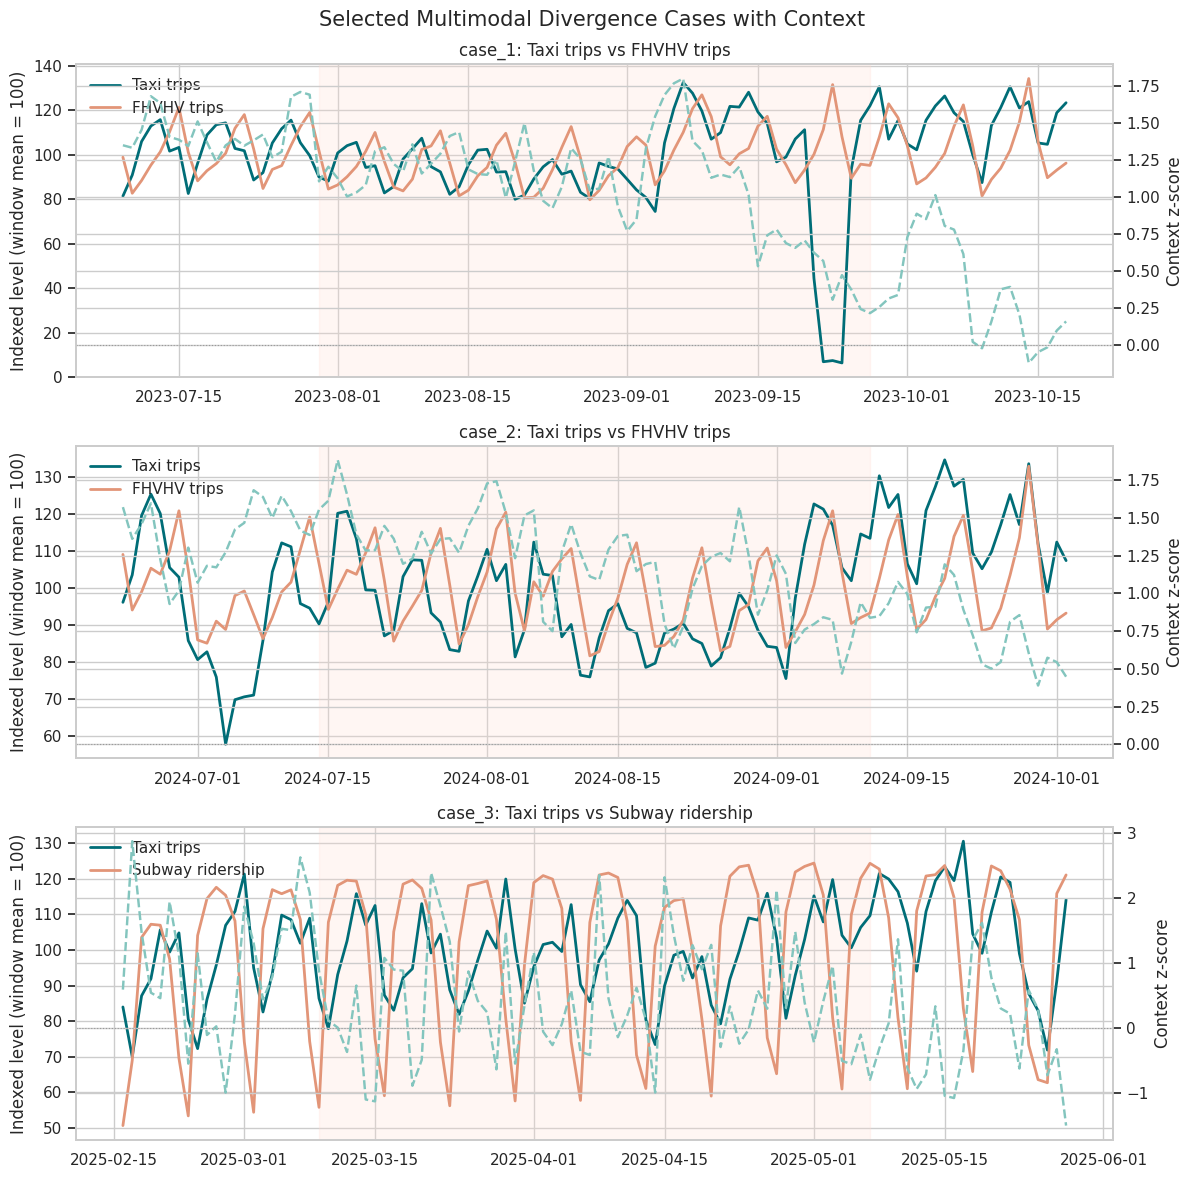

In [25]:
# ---------------------------------------------------------------------
# Visualize the strongest contextual divergence cases
# ---------------------------------------------------------------------

if "case_id" not in divergence_context_summary_df.columns:
    print("No contextual divergence cases were available for plotting.")
else:
    pair_lookup = {
        f"{METRIC_LABELS[x]} vs {METRIC_LABELS[y]}": (x, y)
        for x, y in CONTEXT_CASE_PAIR_DEFINITIONS
    }

    plot_case_df = divergence_context_summary_df.copy()

    # Prefer the contextual signal with the larger absolute case-window z-score.
    plot_case_df["top_context_metric"] = plot_case_df["top_weather_context_metric"]
    plot_case_df["top_context_z"] = plot_case_df["top_weather_context_z"]

    bridge_preferred_mask = (
        plot_case_df["top_bridge_context_z"].abs().fillna(-np.inf)
        > plot_case_df["top_context_z"].abs().fillna(-np.inf)
    )

    plot_case_df.loc[bridge_preferred_mask, "top_context_metric"] = (
        plot_case_df.loc[bridge_preferred_mask, "top_bridge_context_metric"]
    )
    plot_case_df.loc[bridge_preferred_mask, "top_context_z"] = (
        plot_case_df.loc[bridge_preferred_mask, "top_bridge_context_z"]
    )

    plot_case_df = (
        plot_case_df.sort_values("correlation_drop_vs_pair_median")
        .head(3)
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(len(plot_case_df), 1, figsize=(12, 4 * len(plot_case_df)), sharex=False)

    if len(plot_case_df) == 1:
        axes = [axes]

    for ax, (_, case_row) in zip(axes, plot_case_df.iterrows()):
        metric_x, metric_y = pair_lookup[case_row["pair_label"]]

        plot_start = case_row["window_start"] - pd.Timedelta(days=21)
        plot_end = case_row["window_end"] + pd.Timedelta(days=21)

        pair_plot_df = citywide_daily_wide_df.loc[
            citywide_daily_wide_df["date"].between(plot_start, plot_end),
            ["date", metric_x, metric_y],
        ].dropna().copy()

        if pair_plot_df.empty:
            continue

        pair_plot_df[f"{metric_x}__index"] = (
            pair_plot_df[metric_x] / pair_plot_df[metric_x].mean()
        ) * 100
        pair_plot_df[f"{metric_y}__index"] = (
            pair_plot_df[metric_y] / pair_plot_df[metric_y].mean()
        ) * 100

        ax.plot(
            pair_plot_df["date"],
            pair_plot_df[f"{metric_x}__index"],
            color=BRAND_COLORS["dark_teal"],
            linewidth=2,
            label=METRIC_LABELS[metric_x],
        )
        ax.plot(
            pair_plot_df["date"],
            pair_plot_df[f"{metric_y}__index"],
            color=BRAND_COLORS["terracotta"],
            linewidth=2,
            label=METRIC_LABELS[metric_y],
        )

        ax.axvspan(
            case_row["window_start"],
            case_row["window_end"],
            color=BRAND_COLORS["pale_peach"],
            alpha=0.25,
        )

        top_context_metric = case_row["top_context_metric"]
        z_col = f"{top_context_metric}__z" if pd.notna(top_context_metric) else None

        if z_col is not None and z_col in context_daily_df.columns:
            context_plot_df = context_daily_df.loc[
                context_daily_df["date"].between(plot_start, plot_end),
                ["date", z_col],
            ].copy()

            ax2 = ax.twinx()
            ax2.plot(
                context_plot_df["date"],
                context_plot_df[z_col],
                color=BRAND_COLORS["seafoam"],
                linewidth=1.75,
                linestyle="--",
                label=top_context_metric,
            )
            ax2.set_ylabel("Context z-score")
            ax2.axhline(0, color="#999999", linewidth=0.8, linestyle=":")

        ax.set_title(f"{case_row['case_id']}: {case_row['pair_label']}", fontsize=12)
        ax.set_ylabel("Indexed level (window mean = 100)")
        ax.legend(loc="upper left", frameon=False)

    plt.suptitle("Selected Multimodal Divergence Cases with Context", fontsize=15, y=0.98)
    plt.tight_layout()

    if SAVE_FIGURES:
        plt.savefig(
            OUTPUT_DIR / "1.4.2.5_contextual_divergence_cases.png",
            dpi=180,
            bbox_inches="tight",
        )

    plt.show()

Findings\. These case plots mostly reinforce the table result: the contextual layers add some texture, but they do not line up cleanly enough to look like the main driver of the multimodal break\. In case\_1 and case\_2, Taxi trips and FHVHV trips clearly drift apart inside the highlighted window, while the contextual line moves around but does not show one obvious shock that neatly explains the split\. In case\_3, Taxi trips and Subway ridership also lose alignment for a stretch, but again the contextual signal is mixed rather than decisive\. So the practical read is that these divergence windows are real, but Weather and Bridge/Tunnel context seem more like supporting background information than a strong standalone explanation\.

### Section Summary

This section was a pretty modest check on whether Weather or Bridge/Tunnel context helped explain the multimodal relationship breaks we found earlier\. We identified a few of the clearest divergence windows, lined them up against a small set of broad weather signals and bridge/tunnel activity, and found that those context layers added some interpretive texture but not a strong standalone explanation\. In other words, they seem more useful as optional supporting context than as core drivers of the multimodal story\.

## 1\.4\.2\.6 Downstream implications for machine learning models

This final section turns the relationship work into a practical downstream handoff\. The point is not to invent a formal feature\-selection model, but to summarize which core metrics keep showing up as genuinely different signals and which pairs look similar enough that we should watch for overlap later in clustering, anomaly construction, and supervised feature engineering\.

### Identify which base metrics appear complementary versus redundant

We are going to collapse the relationship evidence we already built in earlier sections into one compact pair\-level summary\. For each metric pair, we will combine the full\-period relationship strength, pre/post stability, temporal\-bucket drift, and zone\-level spread so we can judge whether the pair looks potentially redundant, clearly complementary, or related but still distinct\.

In [26]:
# ---------------------------------------------------------------------
# Identify which base metrics appear complementary versus redundant
# ---------------------------------------------------------------------

pair_order = [
    f"{METRIC_LABELS[x]} vs {METRIC_LABELS[y]}"
    for _, x, y in PRIMARY_PAIR_DEFINITIONS + SUPPORTING_PAIR_DEFINITIONS
]

pair_type_lookup = {
    f"{METRIC_LABELS[x]} vs {METRIC_LABELS[y]}": pair_type
    for pair_type, x, y in PRIMARY_PAIR_DEFINITIONS + SUPPORTING_PAIR_DEFINITIONS
}

full_period_relationship_df = (
    pairwise_relationship_summary_df.loc[
        pairwise_relationship_summary_df["period"] == "full_period",
        ["pair_label", "spearman_correlation", "matched_days"],
    ]
    .rename(
        columns={
            "spearman_correlation": "full_period_correlation",
            "matched_days": "matched_days_full_period",
        }
    )
)

pre_post_relationship_df = (
    pairwise_relationship_summary_df.loc[
        pairwise_relationship_summary_df["period"].isin(["pre_cp", "post_cp"]),
        ["pair_label", "period", "spearman_correlation", "matched_days"],
    ]
    .pivot(index="pair_label", columns="period", values=["spearman_correlation", "matched_days"])
)

pre_post_relationship_df.columns = [
    f"{value}_{period}" for value, period in pre_post_relationship_df.columns
]
pre_post_relationship_df = pre_post_relationship_df.reset_index()

bucket_relationship_summary_df = (
    bucket_relationship_change_df.groupby("pair_label", observed=True)
    .agg(
        median_abs_bucket_shift=("correlation_change", lambda s: s.abs().median()),
        max_abs_bucket_shift=("correlation_change", lambda s: s.abs().max()),
        temporal_bucket_count=("temporal_bucket", "nunique"),
    )
    .reset_index()
)

zone_relationship_summary_for_pairs_df = (
    zone_relationship_spread_summary_df.loc[
        :,
        [
            "pair_label",
            "citywide_spearman_correlation",
            "eligible_zone_count",
            "zone_p10_correlation",
            "zone_p50_correlation",
            "zone_p90_correlation",
            "zone_std_correlation",
        ],
    ]
    .copy()
)

zone_relationship_summary_for_pairs_df["zone_iqr_like_spread"] = (
    zone_relationship_summary_for_pairs_df["zone_p90_correlation"]
    - zone_relationship_summary_for_pairs_df["zone_p10_correlation"]
)

metric_pair_distinctiveness_df = (
    full_period_relationship_df
    .merge(pre_post_relationship_df, on="pair_label", how="left")
    .merge(bucket_relationship_summary_df, on="pair_label", how="left")
    .merge(zone_relationship_summary_for_pairs_df, on="pair_label", how="left")
    .assign(
        pair_type=lambda df: df["pair_label"].map(pair_type_lookup),
        abs_full_period_correlation=lambda df: df["full_period_correlation"].abs(),
        abs_pre_cp_correlation=lambda df: df["spearman_correlation_pre_cp"].abs(),
        abs_post_cp_correlation=lambda df: df["spearman_correlation_post_cp"].abs(),
        abs_pre_post_shift=lambda df: (
            df["spearman_correlation_post_cp"] - df["spearman_correlation_pre_cp"]
        ).abs(),
    )
)

# These categories are intentionally heuristic. The goal is not to create a formal
# feature-selection model, but to summarize whether a pair looks persistently overlapping
# or still meaningfully different once we account for regime, time-of-day, and space.
def classify_pair(row):
    strong_and_stable = (
        pd.notna(row["abs_full_period_correlation"])
        and row["abs_full_period_correlation"] >= 0.75
        and pd.notna(row["abs_pre_cp_correlation"])
        and row["abs_pre_cp_correlation"] >= 0.70
        and pd.notna(row["abs_post_cp_correlation"])
        and row["abs_post_cp_correlation"] >= 0.70
        and pd.notna(row["median_abs_bucket_shift"])
        and row["median_abs_bucket_shift"] <= 0.10
        and pd.notna(row["zone_iqr_like_spread"])
        and row["zone_iqr_like_spread"] <= 0.25
    )

    clearly_distinct = (
        pd.notna(row["abs_full_period_correlation"])
        and (
            row["abs_full_period_correlation"] < 0.45
            or row["median_abs_bucket_shift"] > 0.15
            or row["zone_iqr_like_spread"] > 0.45
        )
    )

    if strong_and_stable:
        return "potentially_redundant"
    if clearly_distinct:
        return "complementary"
    return "related_but_distinct"

metric_pair_distinctiveness_df["relationship_role"] = (
    metric_pair_distinctiveness_df.apply(classify_pair, axis=1)
)

metric_pair_distinctiveness_df["relationship_summary"] = np.select(
    [
        metric_pair_distinctiveness_df["relationship_role"] == "potentially_redundant",
        metric_pair_distinctiveness_df["relationship_role"] == "complementary",
    ],
    [
        "strong, stable overlap across period, bucket, and space",
        "meaningfully different signal across period, bucket, or space",
    ],
    default="related, but still carrying distinct structure",
)

metric_pair_distinctiveness_df = (
    metric_pair_distinctiveness_df.loc[
        metric_pair_distinctiveness_df["pair_label"].isin(pair_order)
    ]
    .assign(
        relationship_role=pd.Categorical(
            metric_pair_distinctiveness_df["relationship_role"],
            categories=[
                "potentially_redundant",
                "related_but_distinct",
                "complementary",
            ],
            ordered=True,
        )
    )
    .sort_values(
        ["relationship_role", "abs_full_period_correlation"],
        ascending=[True, False],
    )
    .round(3)
    .reset_index(drop=True)
)

display(
    metric_pair_distinctiveness_df[
        [
            "pair_label",
            "pair_type",
            "full_period_correlation",
            "spearman_correlation_pre_cp",
            "spearman_correlation_post_cp",
            "abs_pre_post_shift",
            "median_abs_bucket_shift",
            "zone_iqr_like_spread",
            "eligible_zone_count",
            "relationship_role",
            "relationship_summary",
        ]
    ]
)

,pair_label,pair_type,full_period_correlation,spearman_correlation_pre_cp,spearman_correlation_post_cp,abs_pre_post_shift,median_abs_bucket_shift,zone_iqr_like_spread,eligible_zone_count,relationship_role,relationship_summary
0,Taxi trips vs Taxi average speed,supporting_same_modality,-0.619,-0.769,-0.599,0.170,0.077,NaN,NaN,related_but_distinct,"related, but still carrying distinct structure"
1,Subway ridership vs Average bus speed,primary_cross_modality,-0.698,-0.805,-0.766,0.039,0.131,0.607,155.0,complementary,"meaningfully different signal across period, b..."
2,Taxi average speed vs Average bus speed,primary_cross_modality,0.693,0.698,0.741,0.044,0.049,0.523,247.0,complementary,"meaningfully different signal across period, b..."
3,Taxi trips vs FHVHV trips,primary_cross_modality,0.576,0.517,0.654,0.137,0.049,0.518,261.0,complementary,"meaningfully different signal across period, b..."
4,Taxi trips vs Subway ridership,primary_cross_modality,0.567,0.613,0.450,0.163,0.037,0.493,156.0,complementary,"meaningfully different signal across period, b..."
5,FHVHV trips vs FHVHV average speed,supporting_same_modality,-0.319,-0.299,-0.337,0.039,0.072,NaN,NaN,complementary,"meaningfully different signal across period, b..."
6,Taxi trips vs Average bus speed,primary_cross_modality,-0.287,-0.505,-0.334,0.171,0.056,0.663,252.0,complementary,"meaningfully different signal across period, b..."
7,FHVHV trips vs Subway ridership,primary_cross_modality,-0.079,-0.155,-0.042,0.113,0.053,0.767,156.0,complementary,"meaningfully different signal across period, b..."


This quick visual turns the pair\-level summary into a cleaner read\. It is not trying to replace the detailed relationship sections above\. It is just a compact way to see which metric pairs stay tightly aligned and which ones look more distinct once we account for policy regime, time\-of\-day structure, and spatial variation\.

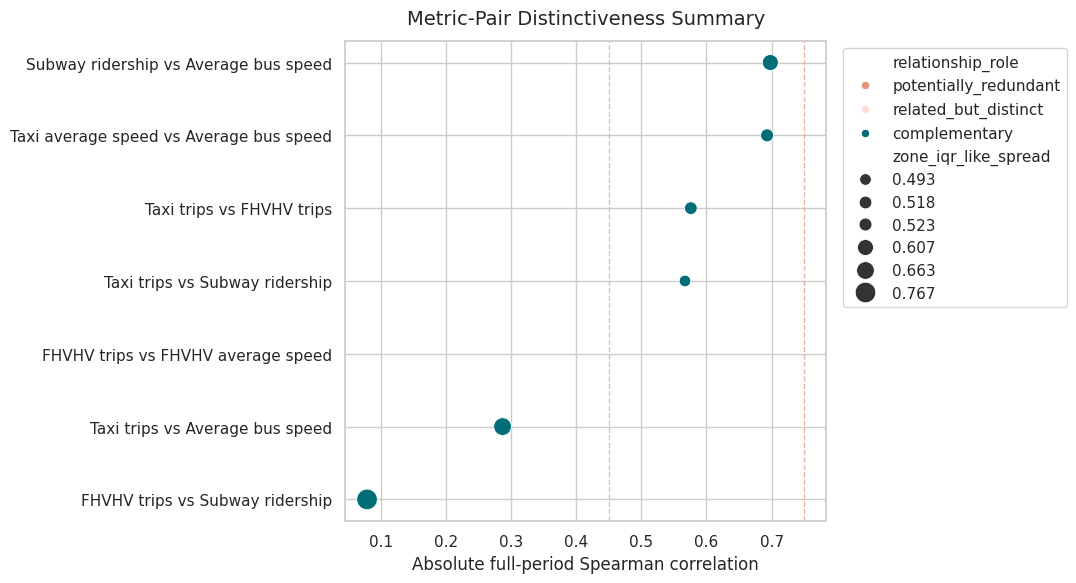

In [27]:
# ---------------------------------------------------------------------
# Visualize which metric pairs look more overlapping versus distinct
# ---------------------------------------------------------------------

relationship_role_score = {
    "potentially_redundant": 0,
    "related_but_distinct": 1,
    "complementary": 2,
}

metric_pair_plot_df = metric_pair_distinctiveness_df.copy()
metric_pair_plot_df["relationship_role_score"] = (
    metric_pair_plot_df["relationship_role"].map(relationship_role_score)
)

metric_pair_plot_df = metric_pair_plot_df.sort_values(
    ["relationship_role_score", "abs_full_period_correlation"],
    ascending=[True, False],
)

role_palette = {
    "potentially_redundant": BRAND_COLORS["terracotta"],
    "related_but_distinct": BRAND_COLORS["pale_peach"],
    "complementary": BRAND_COLORS["dark_teal"],
}

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=metric_pair_plot_df,
    x="abs_full_period_correlation",
    y="pair_label",
    hue="relationship_role",
    size="zone_iqr_like_spread",
    sizes=(70, 220),
    palette=role_palette,
    edgecolor="white",
    linewidth=0.6,
)

plt.axvline(0.75, color=BRAND_COLORS["terracotta"], linestyle="--", linewidth=1, alpha=0.7)
plt.axvline(0.45, color=BRAND_COLORS["seafoam"], linestyle="--", linewidth=1, alpha=0.7)

plt.title("Metric-Pair Distinctiveness Summary", fontsize=14, pad=12)
plt.xlabel("Absolute full-period Spearman correlation")
plt.ylabel("")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        OUTPUT_DIR / "1.4.2.5_metric_pair_distinctiveness_summary.png",
        dpi=180,
        bbox_inches="tight",
    )

plt.show()

Findings\. This summary argues pretty strongly against treating any of the core backbone metrics as outright redundant\. Even the pairs with the strongest overall alignment, like Subway ridership vs Average bus speed and Taxi average speed vs Average bus speed, still show enough temporal\-bucket drift or zone\-level spread to count as distinct rather than interchangeable\. Taxi trips vs FHVHV trips and Taxi trips vs Subway ridership are moderately aligned at the citywide level, but both relationships move meaningfully across policy regime and space, which makes them useful as separate signals rather than duplicate ones\. FHVHV trips vs Subway ridership is the clearest example of why this matters: the full\-period relationship is close to zero, but the very wide zone\-level spread shows that the aggregate is hiding very different local patterns\. The only pair that looks somewhat closer to overlap is Taxi trips vs Taxi average speed, but even that still shifts enough across regimes to stay in the “related but distinct” bucket\. So the downstream takeaway is pretty clean: keep the current base metrics, stay alert to relationship structure, but do not collapse this metric set on redundancy grounds\.

## Close

> Clustering Insights\. The multimodal EDA indicates that all six core metrics contribute distinct information\. Taxi, FHVHV, Subway, and Bus often move together at broad scales, but their relationships vary meaningfully across Taxi Zones, temporal buckets, and policy periods\. Demand and speed also capture different dimensions of mobility behavior, so neither should be removed simply because some metric pairs are correlated overall\.

For downstream clustering, the six\-metric backbone should be retained, while Traffic, Bridge/Tunnel, and Weather remain outside the primary mobility\-profile feature space\. The local heterogeneity observed in multimodal relationships also suggests that simple period\-level means may be insufficient; temporal shape should be preserved, and a small set of multimodal relationship features may be evaluated in 1\.4\.3\. Those relationship features should only be retained if they add stable, interpretable structure beyond the marginal mobility profiles\.

> This notebook helped clarify which mobility signals are genuinely carrying different information and which relationships are stable enough to trust downstream\. Taxi trips, FHVHV trips, Subway ridership, and the speed metrics do not collapse into one interchangeable signal; they stay distinct enough across time and space to justify carrying them forward separately\. The most stable relationship structure is the familiar shared\-demand alignment and the inverse demand\-versus\-speed tradeoff, while true substitution\-like patterns look much more local and situational\. For the later clustering, anomaly, and supervised\-learning notebooks, the main implication is to preserve the base metrics as separate signals, respect zone\-level heterogeneity, and treat multimodal relationship structure as useful modeling signal rather than just descriptive background\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5c43663c-345d-4c21-9332-dd4f928af3ba' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>